# Multi-Class Mental Health Detection Using Transformers and SHAP
### Pooja Chandra — 24333891 — MSc Artificial Intelligence — National College of Ireland

**Models:** Logistic Regression | SVM | MentalBERT | MentalRoBERTa
**Datasets:** 3 licensed datasets
**Novel Contribution:** Cross-condition SHAP analysis

---
## Notebook Structure
1. Install & Import Libraries
2. Download Project Files & Load Datasets
3. Merge & Preprocess Data
4. Exploratory Data Analysis (EDA)
5. Train/Val/Test Split
6. Baseline Models (LR + SVM)
7. MentalBERT Fine-Tuning
8. MentalRoBERTa Fine-Tuning
9. Model Comparison & Evaluation
10. McNemar's Statistical Test
11. SHAP Cross-Condition Explainability
12. LLM Benchmarking — Zero-Shot & Few-Shot (Llama 3.3 70B via Groq)

## Step 1 — Install & Import Libraries

In [1]:
# Install required libraries
!pip install transformers torch datasets shap scikit-learn pandas numpy matplotlib seaborn scipy -q
print("All libraries installed!")


All libraries installed!


In [2]:
# Install NLTK and download required resources
!pip install nltk -q
import nltk
nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)
nltk.download('omw-1.4',    quiet=True)
print("NLTK resources downloaded!")

NLTK resources downloaded!


In [3]:

from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)
print("Logged in to HuggingFace!")


Logged in to HuggingFace!


In [4]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from scipy.stats import chi2

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from transformers import logging as hf_logging
from torch.optim import AdamW
from tqdm.notebook import tqdm

# Suppress verbose HuggingFace load reports
hf_logging.set_verbosity_error()

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


## Step 2 — Download Project Files & Load Datasets


In [5]:
!pip -q install gdown

import gdown

folder_url = "https://drive.google.com/drive/folders/1bMz3bCb-GQb_vJciKriB-EVzJ1LY0crx?usp=sharing"

gdown.download_folder(
    folder_url,
    output="/content/mental_health_data",
    quiet=False
)




Retrieving folder contents


Retrieving folder 1Rw2YpUEyV_Yui8zwqejbmEeALI38_s0O models
Retrieving folder 1aR4PAsQ-xD25V--uwVJ9TcCoWFQbc6fT mentalbert
Processing file 1ojnyP8vhcqtH5yr1dO1HuUKiRX7XCLoV config.json
Processing file 1vlRD6tJ3Icr3OPltZirhdED3jYtNBp3V model.safetensors
Processing file 1Dfzg-2YcogjudRgc0ICeVamd1C8zIu4Q tokenizer_config.json
Processing file 17pvVnD9vyr0gkw7E_vj0uboMrS-yDNgZ tokenizer.json
Retrieving folder 1Lek6yXFcXr3yTo-7RRZ3RdhEAlD1LZrV mentalroberta
Processing file 1DsMAEntdY6kr-0fYXhCJFryCw-poAAsB config.json
Processing file 1bwoQNnzEwpEpVlY9NSQKP0CJ_ERlx5RT model.safetensors
Processing file 1cMt_cKplFjuF87PnGryTl7M9KmRmg9f_ tokenizer_config.json
Processing file 1efHwlmDTsGlo_FFpS2EASj8e_0MzmmIA tokenizer.json
Processing file 1M8VftYli_Hit1h_cv2nqQx-3FkYjXucE ds1_sentiment_mh.csv
Processing file 1k-KnajaTVy9We0a9vFqwVh5GCvsKwTtS ds2_mental_health_classification.csv
Processing file 11s4MQDwWQTSHqs-2E8aFn-zd9vgiYneZ ds3_mental_health_text.csv
Processing file 1B1dRfFdpc63jaanP_uHBsJQPS3

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1ojnyP8vhcqtH5yr1dO1HuUKiRX7XCLoV
To: /content/mental_health_data/models/mentalbert/config.json
100%|██████████| 1.15k/1.15k [00:00<00:00, 4.52MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1vlRD6tJ3Icr3OPltZirhdED3jYtNBp3V
From (redirected): https://drive.google.com/uc?id=1vlRD6tJ3Icr3OPltZirhdED3jYtNBp3V&confirm=t&uuid=efc37f60-d44d-4f94-a263-4ca5ac8103f9
To: /content/mental_health_data/models/mentalbert/model.safetensors
100%|██████████| 438M/438M [00:02<00:00, 187MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Dfzg-2YcogjudRgc0ICeVamd1C8zIu4Q
To: /content/mental_health_data/models/mentalbert/tokenizer_config.json
100%|██████████| 351/351 [00:00<00:00, 202kB/s]
Downloading...
From: https://drive.google.com/uc?id=17pvVnD9vyr0gkw7E_vj0uboMrS-yDNgZ
To: /content/mental_health_data/models/mentalbert/t

['/content/mental_health_data/models/mentalbert/config.json',
 '/content/mental_health_data/models/mentalbert/model.safetensors',
 '/content/mental_health_data/models/mentalbert/tokenizer_config.json',
 '/content/mental_health_data/models/mentalbert/tokenizer.json',
 '/content/mental_health_data/models/mentalroberta/config.json',
 '/content/mental_health_data/models/mentalroberta/model.safetensors',
 '/content/mental_health_data/models/mentalroberta/tokenizer_config.json',
 '/content/mental_health_data/models/mentalroberta/tokenizer.json',
 '/content/mental_health_data/ds1_sentiment_mh.csv',
 '/content/mental_health_data/ds2_mental_health_classification.csv',
 '/content/mental_health_data/ds3_mental_health_text.csv',
 '/content/mental_health_data/Mental_Health_Detection_Colab.ipynb']

In [6]:
llm_results_url = "https://drive.google.com/drive/folders/1rQ4eo_xl042HXKWcBpIAIjDCvKFU9I9D?usp=sharing"

gdown.download_folder(
    llm_results_url,
    output="/content/llm_results/",
    quiet=False
)


Retrieving folder contents


Processing file 1WG2hQqKUou1Ug6dL6KOOooaBssWvhyh8 fs_cache.pkl
Processing file 1IzdpUFMgkGYeSQFrc_yZgGOrnIX3WJCc fs_preds.npy
Processing file 19G83s0kWHkw7AaOyZVMdIaaY0F5nBJag llm_fs_results.pkl
Processing file 1WxrpA3uw-5QXO9jzCsDGrHJDc4iPr9a1 llm_test_subset.csv
Processing file 173DpdANXt1m-59r8wJIfq_fOS6fd9S02 y_llm_true.npy
Processing file 1kuyekd9Zm4SHtW6IKLVYoSUaZBd1EErq zs_cache.pkl


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1WG2hQqKUou1Ug6dL6KOOooaBssWvhyh8
To: /content/llm_results/llm_results/fs_cache.pkl
100%|██████████| 4.18k/4.18k [00:00<00:00, 3.88MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IzdpUFMgkGYeSQFrc_yZgGOrnIX3WJCc
To: /content/llm_results/llm_results/fs_preds.npy
100%|██████████| 1.81k/1.81k [00:00<00:00, 7.37MB/s]
Downloading...
From: https://drive.google.com/uc?id=19G83s0kWHkw7AaOyZVMdIaaY0F5nBJag
To: /content/llm_results/llm_results/llm_fs_results.pkl
100%|██████████| 4.15k/4.15k [00:00<00:00, 5.22MB/s]
Downloading...
From: https://drive.google.com/uc?id=1WxrpA3uw-5QXO9jzCsDGrHJDc4iPr9a1
To: /content/llm_results/llm_results/llm_test_subset.csv
100%|██████████| 407k/407k [00:00<00:00, 87.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=173DpdANXt1m-59r8wJIfq_fOS6fd9S02
To: /content/llm_results/llm_results/y_llm

['/content/llm_results/llm_results/fs_cache.pkl',
 '/content/llm_results/llm_results/fs_preds.npy',
 '/content/llm_results/llm_results/llm_fs_results.pkl',
 '/content/llm_results/llm_results/llm_test_subset.csv',
 '/content/llm_results/llm_results/y_llm_true.npy',
 '/content/llm_results/llm_results/zs_cache.pkl']

In [7]:
DATA_PATH = "/content/mental_health_data/"
SAVE_DIR = "/content/llm_results/llm_results/"


In [8]:
# STEP 1: LOAD EACH DATASET INDIVIDUALLY
print("="*60)
print("STEP 1 — Loading 3 Independent Datasets")
print("="*60)

# DS1 — Sentiment Analysis for Mental Health
# Source : Kaggle (suchintikasarkar) | License: DbCL v1.0 | 53,043 rows | 7 classes
ds1 = pd.read_csv(DATA_PATH + 'ds1_sentiment_mh.csv')
ds1 = ds1[['statement', 'status']].rename(columns={'statement': 'text'})
ds1['source'] = 'DS1_Kaggle'
print(f"\nDS1 (Kaggle, DbCL v1.0)        : {len(ds1):,} rows | Classes: {sorted(ds1['status'].unique())}")

# DS2 — Mental Health Condition Classification
# Source : HuggingFace (sai1908) | License: MIT | 103,488 rows | 7 classes
ds2 = pd.read_csv(DATA_PATH + 'ds2_mental_health_classification.csv')
ds2 = ds2[['text', 'status']]
ds2['source'] = 'DS2_HuggingFace'
print(f"DS2 (HuggingFace, MIT)         : {len(ds2):,} rows | Classes: {sorted(ds2['status'].unique())}")

# DS3 — Mental Health Text Classification Dataset
# Source : HuggingFace (ourafla) | License: CC-BY-4.0 | 49,612 raw rows | 4 classes
# IMPORTANT: DS3 was constructed using DS1 as its source (~79.5% overlap)
ds3_raw = pd.read_csv(DATA_PATH + 'ds3_mental_health_text.csv')
ds3_raw = ds3_raw[['text', 'status']]
print(f"DS3 (HuggingFace, CC-BY-4.0)    : {len(ds3_raw):,} raw rows | Classes: {sorted(ds3_raw['status'].unique())}")

# STEP 2: CROSS-DATASET DEDUPLICATION (DS3 vs DS1 & DS2)
# Remove DS3 rows that already exist in DS1 or DS2 using exact-text matching
print("\n" + "="*60)
print("STEP 2 — Cross-Dataset Deduplication (Before Merging)")
print("="*60)

# Build normalised text key for matching (lowercase + stripped)
ds1_texts = set(ds1['text'].astype(str).str.strip().str.lower())
ds2_texts = set(ds2['text'].astype(str).str.strip().str.lower())
block_set = ds1_texts | ds2_texts

ds3_raw['_key'] = ds3_raw['text'].astype(str).str.strip().str.lower()
matched_mask   = ds3_raw['_key'].isin(block_set)
matched_count  = matched_mask.sum()

# Keep only DS3 rows that do NOT match DS1 or DS2
ds3 = ds3_raw[~matched_mask].drop(columns=['_key']).reset_index(drop=True)
ds3['source'] = 'DS3_HuggingFace'

overlap_pct = matched_count / len(ds3_raw) * 100
print(f"\nDS3 raw rows                   : {len(ds3_raw):,}")
print(f"Matched DS1 or DS2 (removed)   : {matched_count:,} rows ({overlap_pct:.1f}%)")
print(f"DS3 unique rows (kept)         : {len(ds3):,}")
print(f"\n✅ DS3 now contributes {len(ds3):,} genuinely independent samples")
print(f"   covering classes: {sorted(ds3['status'].unique())}")


STEP 1 — Loading 3 Independent Datasets

DS1 (Kaggle, DbCL v1.0)        : 53,043 rows | Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
DS2 (HuggingFace, MIT)         : 103,488 rows | Classes: ['anxiety', 'bipolar', 'depression', 'normal', 'personality disorder', 'stress', 'suicidal']
DS3 (HuggingFace, CC-BY-4.0)    : 49,612 raw rows | Classes: ['Anxiety', 'Depression', 'Normal', 'Suicidal']

STEP 2 — Cross-Dataset Deduplication (Before Merging)

DS3 raw rows                   : 49,612
Matched DS1 or DS2 (removed)   : 39,469 rows (79.6%)
DS3 unique rows (kept)         : 10,143

✅ DS3 now contributes 10,143 genuinely independent samples
   covering classes: ['Anxiety', 'Depression', 'Normal', 'Suicidal']


## Step 3 — Merge & Preprocess Data

In [9]:
# STEP 3: MERGE THE THREE DEDUPLICATED DATASETS
print("="*60)
print("STEP 3 — Merging 3 Deduplicated Datasets")
print("="*60)

combined = pd.concat([ds1[['text','status','source']],
                      ds2[['text','status','source']],
                      ds3[['text','status','source']]], ignore_index=True)

# Standardise labels to lowercase
combined['status'] = combined['status'].str.lower().str.strip()
print(f"\nAfter merging 3 datasets       : {len(combined):,} rows")

# STEP 4: STANDARD CLEANING
print("\n" + "="*60)
print("STEP 4 — Standard Cleaning")
print("="*60)

# Remove null/empty texts
combined = combined.dropna(subset=['text'])
combined = combined[combined['text'].str.strip() != '']
print(f"\nAfter null removal             : {len(combined):,} rows")

# Residual deduplication check (should be near zero since DS3 was pre-deduplicated)
before_dedup = len(combined)
combined = combined.drop_duplicates(subset=['text'])
residual = before_dedup - len(combined)
residual_pct = residual / before_dedup * 100
print(f"After residual dedup check     : {len(combined):,} rows")
print(f"Residual duplicates removed    : {residual:,} ({residual_pct:.2f}%) — confirms cross-dataset dedup worked")

print(f"\n✅ Final clean dataset          : {len(combined):,} unique samples")
print(f"\n📊 Class distribution:")
print(combined['status'].value_counts())


STEP 3 — Merging 3 Deduplicated Datasets

After merging 3 datasets       : 166,674 rows

STEP 4 — Standard Cleaning

After null removal             : 166,312 rows
After residual dedup check     : 151,093 rows
Residual duplicates removed    : 15,219 (9.15%) — confirms cross-dataset dedup worked

✅ Final clean dataset          : 151,093 unique samples

📊 Class distribution:
status
depression              29517
normal                  25691
anxiety                 23761
suicidal                23681
stress                  17490
bipolar                 16177
personality disorder    14776
Name: count, dtype: int64


In [10]:
# Define label mapping — 7 classes
LABEL2ID = {
    'normal': 0,
    'depression': 1,
    'anxiety': 2,
    'stress': 3,
    'bipolar': 4,
    'personality disorder': 5,
    'suicidal': 6
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_CLASSES = 7
CLASS_NAMES = [ID2LABEL[i] for i in range(NUM_CLASSES)]

# Apply label mapping
combined = combined[combined['status'].isin(LABEL2ID.keys())]
combined['label_id'] = combined['status'].map(LABEL2ID)

print("Final dataset size:", len(combined))
print("Label mapping:", LABEL2ID)


Final dataset size: 151093
Label mapping: {'normal': 0, 'depression': 1, 'anxiety': 2, 'stress': 3, 'bipolar': 4, 'personality disorder': 5, 'suicidal': 6}


In [11]:
# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)   # Remove URLs
    text = re.sub(r'@\w+', '', text)                  # Remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)            # Remove # but keep word
    text = re.sub(r'[^a-z\s\'.,!?]', ' ', text)     # Keep letters and basic punctuation
    text = re.sub(r'\s+', ' ', text).strip()          # Remove extra spaces
    return text

# Apply cleaning
print("Cleaning text...")
combined['text'] = combined['text'].apply(clean_text)

# Remove very short texts (less than 5 words)
combined = combined[combined['text'].str.split().str.len() >= 5]
combined = combined.reset_index(drop=True)

print("After cleaning:", len(combined), "samples")
print("\nSample cleaned texts:")
for i in range(3):
    print(f"  [{combined['status'][i]}]: {combined['text'][i][:100]}...")


Cleaning text...
After cleaning: 147139 samples

Sample cleaned texts:
  [anxiety]: trouble sleeping, confused mind, restless heart. all out of tune...
  [anxiety]: all wrong, back off dear, forward doubt. stay in a restless and restless place...
  [anxiety]: i've shifted my focus to something else but i'm still worried...


In [12]:
# ── NLP Preprocessing: Tokenisation → Stopword Removal → Stemming → Lemmatisation ─
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

STOPWORDS   = set(stopwords.words('english'))
stemmer     = PorterStemmer()
lemmatizer  = WordNetLemmatizer()

def tokenize_remove_stopwords(text):
    """Tokenise, lowercase, remove stopwords and non-alpha tokens."""
    tokens = word_tokenize(str(text).lower())
    return [t for t in tokens if t.isalpha() and t not in STOPWORDS]

def apply_stemming(tokens):
    """Apply Porter Stemming to a list of tokens."""
    return [stemmer.stem(t) for t in tokens]

def apply_lemmatization(tokens):
    """Apply WordNet Lemmatization to a list of tokens."""
    return [lemmatizer.lemmatize(t) for t in tokens]

print("Applying NLP preprocessing pipeline...")

# Step-by-step columns for EDA and analysis
combined['text_tokens']     = combined['text'].apply(tokenize_remove_stopwords)
combined['text_stemmed']    = combined['text_tokens'].apply(apply_stemming)
combined['text_lemmatized'] = combined['text_tokens'].apply(apply_lemmatization)

# Joined string versions (used for TF-IDF baseline and EDA word counts)
combined['text_nlp']        = combined['text_lemmatized'].apply(lambda x: ' '.join(x))

print("Done!\n")
print("── Sample ──────────────────────────────────────────────────")
sample_text   = combined['text'][0]
sample_tokens = combined['text_tokens'][0]
sample_stem   = combined['text_stemmed'][0]
sample_lemma  = combined['text_lemmatized'][0]
print(f"Original     : {sample_text[:90]}")
print(f"Tokenised    : {sample_tokens[:10]}")
print(f"Stemmed      : {sample_stem[:10]}")
print(f"Lemmatized   : {sample_lemma[:10]}")
print(f"\nAvg tokens (before stopword removal) : {combined['text'].str.split().str.len().mean():.1f} words")
print(f"Avg tokens (after  stopword removal) : {combined['text_tokens'].str.len().mean():.1f} words")

Applying NLP preprocessing pipeline...
Done!

── Sample ──────────────────────────────────────────────────
Original     : trouble sleeping, confused mind, restless heart. all out of tune
Tokenised    : ['trouble', 'sleeping', 'confused', 'mind', 'restless', 'heart', 'tune']
Stemmed      : ['troubl', 'sleep', 'confus', 'mind', 'restless', 'heart', 'tune']
Lemmatized   : ['trouble', 'sleeping', 'confused', 'mind', 'restless', 'heart', 'tune']

Avg tokens (before stopword removal) : 102.5 words
Avg tokens (after  stopword removal) : 46.7 words


## Step 4 — Exploratory Data Analysis (EDA)

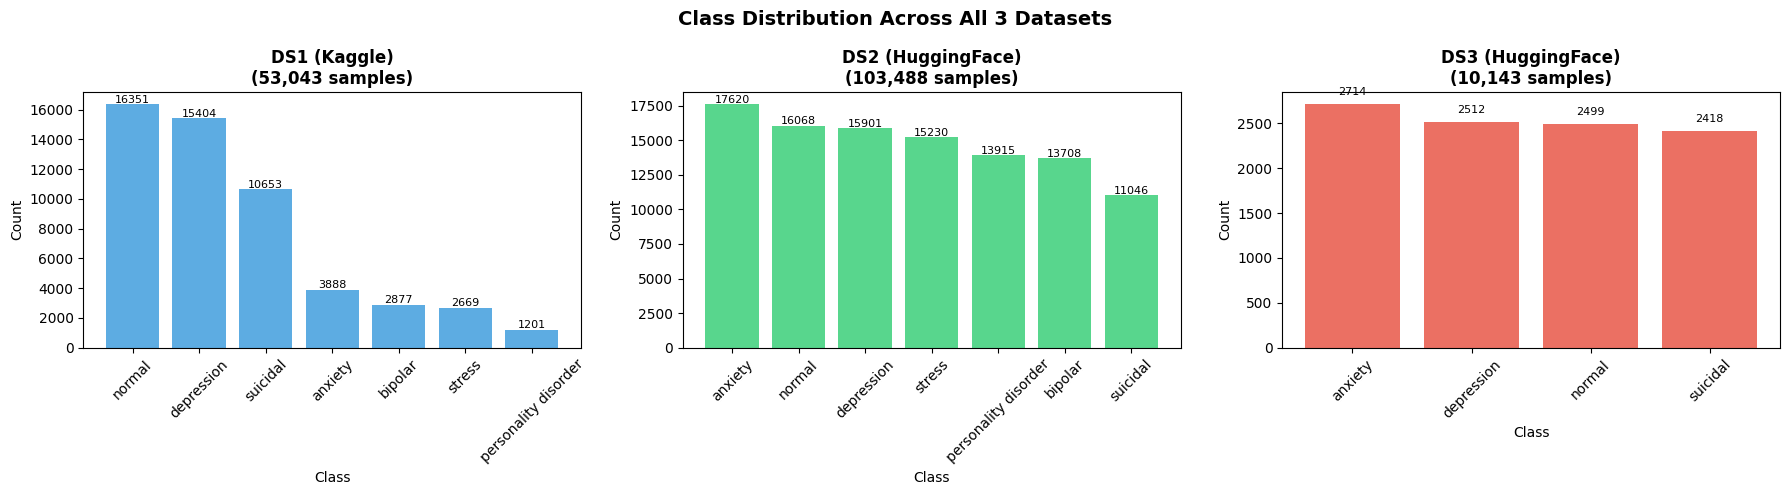

Plot saved!


In [13]:
# Plot 1 — Class Distribution for each dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = {'DS1 (Kaggle)': ds1, 'DS2 (HuggingFace)': ds2, 'DS3 (HuggingFace)': ds3}
colors = ['#3498db', '#2ecc71', '#e74c3c']

for ax, (name, df), color in zip(axes, datasets.items(), colors):
    dist = df['status'].str.lower().value_counts()
    ax.bar(dist.index, dist.values, color=color, alpha=0.8)
    ax.set_title(f'{name}\n({len(df):,} samples)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(dist.values):
        ax.text(i, v + 100, str(v), ha='center', fontsize=8)

plt.suptitle('Class Distribution Across All 3 Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")


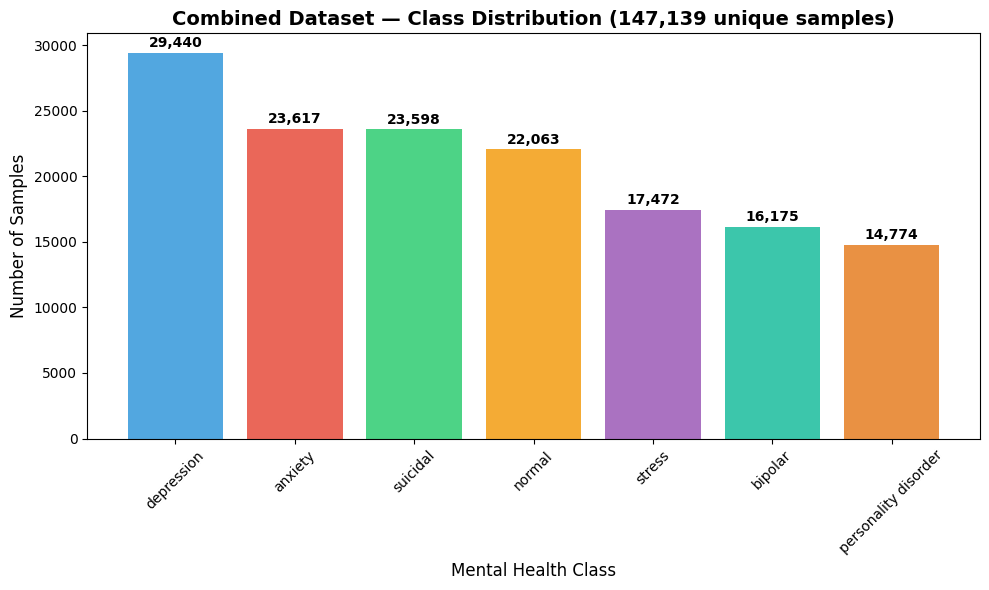


Imbalance ratio  : 1.99x
Most frequent    : depression (29,440)
Least frequent   : personality disorder (14,774)


In [14]:
# Plot 2 — Combined Dataset Distribution
fig, ax = plt.subplots(figsize=(10, 6))

dist = combined['status'].value_counts()
bars = ax.bar(dist.index, dist.values,
              color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22'],
              alpha=0.85)

ax.set_title(f'Combined Dataset — Class Distribution ({len(combined):,} unique samples)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mental Health Class', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('combined_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = round(dist.max()/dist.min(), 2)
print(f"\nImbalance ratio  : {imbalance_ratio}x")
print(f"Most frequent    : {dist.idxmax()} ({dist.max():,})")
print(f"Least frequent   : {dist.idxmin()} ({dist.min():,})")


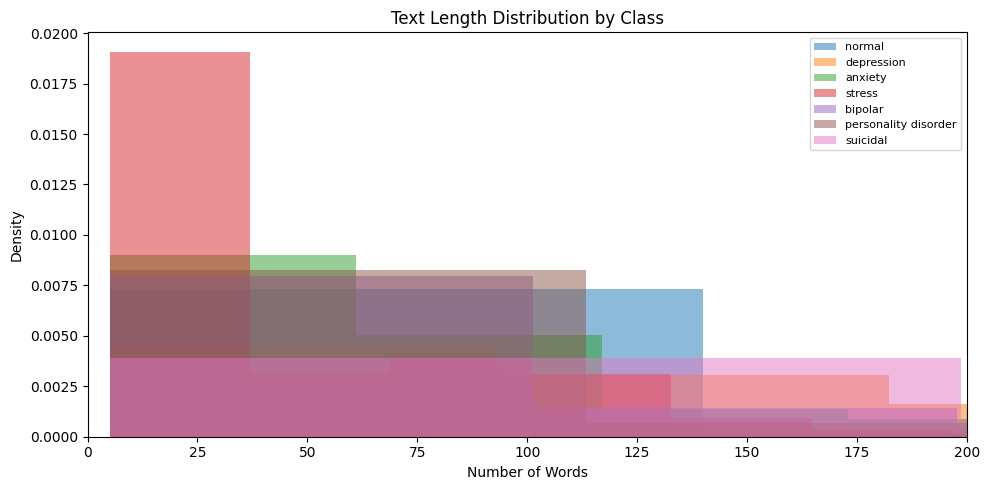

Average text length: 102.5 words
Max text length: 9684 words


In [15]:
# Plot 3 — Text length distribution
combined['text_length'] = combined['text'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 5))
for label in CLASS_NAMES:
    subset = combined[combined['status'] == label]['text_length']
    ax.hist(subset, bins=50, alpha=0.5, label=label, density=True)

ax.set_xlabel('Number of Words')
ax.set_ylabel('Density')
ax.set_title('Text Length Distribution by Class')
ax.set_xlim(0, 200)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('text_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average text length:", round(combined['text_length'].mean(), 1), "words")
print("Max text length:", combined['text_length'].max(), "words")


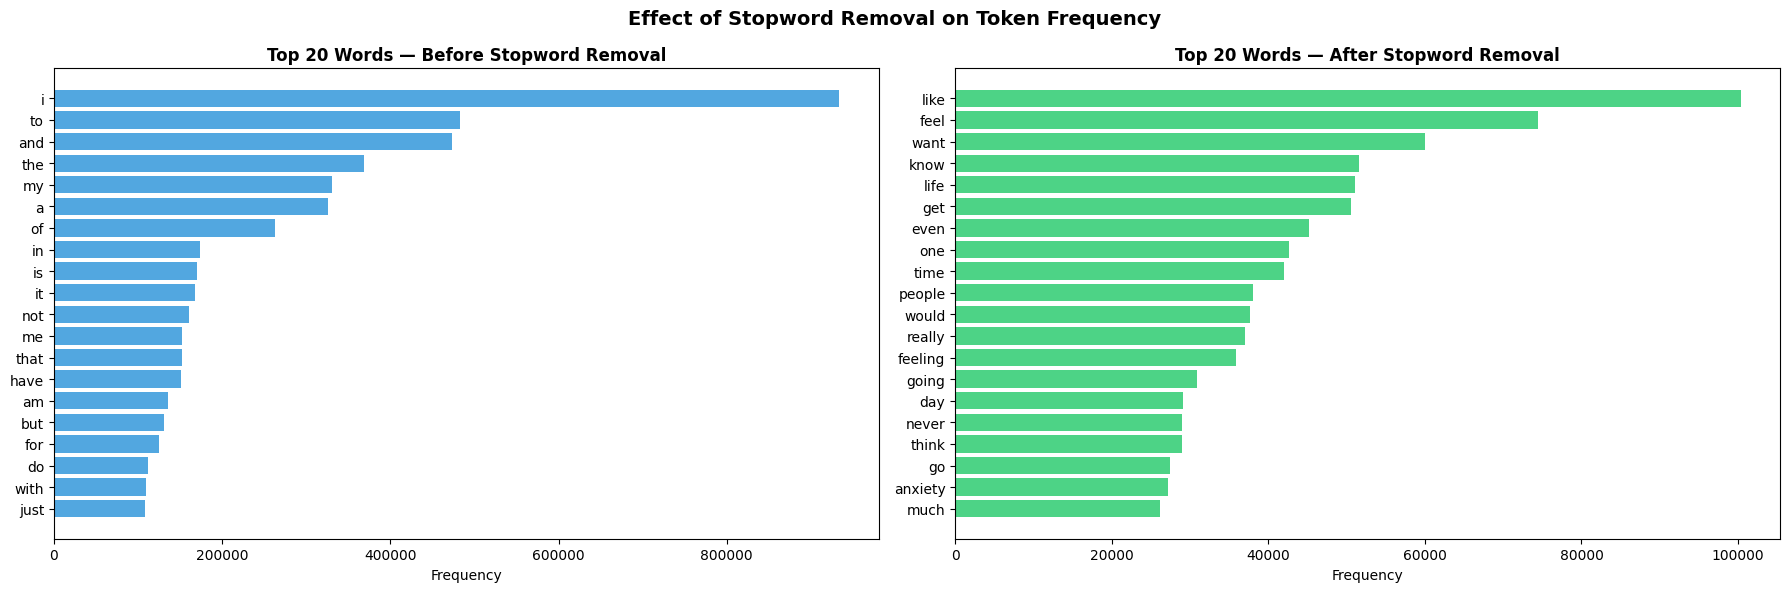

Plot saved: stopword_comparison.png


In [16]:
# ── EDA Plot 4 — Top 20 Words: Before vs After Stopword Removal
from collections import Counter

def get_top_words(series_of_text, n=20):
    all_words = [w for text in series_of_text for w in str(text).split()]
    return Counter(all_words).most_common(n)

# Before: raw cleaned text
before = get_top_words(combined['text'], 20)
# After:  stopwords removed (tokenised)
after  = get_top_words(combined['text_tokens'].apply(lambda x: ' '.join(x)), 20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

words_b, counts_b = zip(*before)
axes[0].barh(list(reversed(words_b)), list(reversed(counts_b)), color='#3498db', alpha=0.85)
axes[0].set_title('Top 20 Words — Before Stopword Removal', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')

words_a, counts_a = zip(*after)
axes[1].barh(list(reversed(words_a)), list(reversed(counts_a)), color='#2ecc71', alpha=0.85)
axes[1].set_title('Top 20 Words — After Stopword Removal', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('Effect of Stopword Removal on Token Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('stopword_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: stopword_comparison.png")

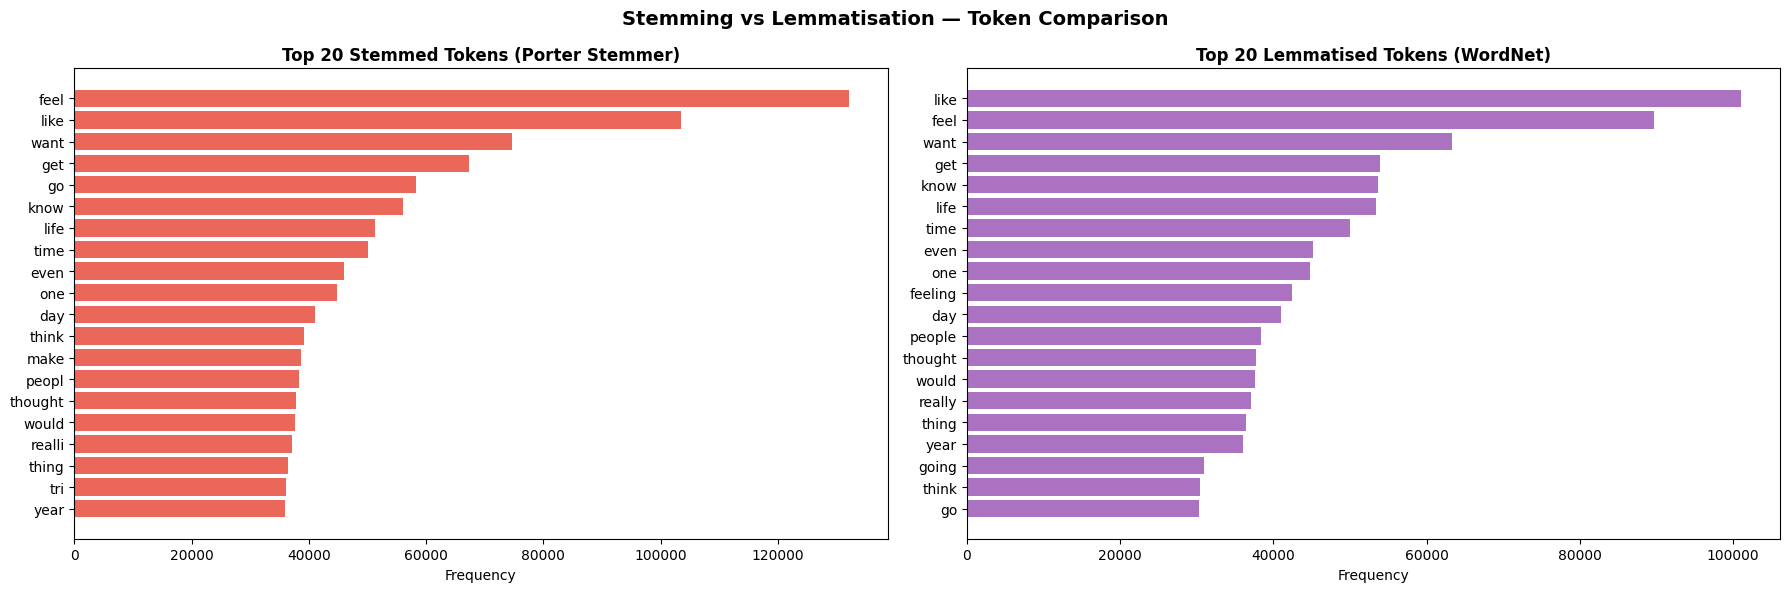


── Stemming vs Lemmatisation — Word Examples ───────────────
Original           Stemmed            Lemmatized        
------------------------------------------------------
running            run                running           
better             better             better            
feeling            feel               feeling           
depression         depress            depression        
anxious            anxiou             anxious           
suicidal           suicid             suicidal          
worried            worri              worried           
crying             cri                cry               
Plot saved: stem_vs_lemma.png


In [17]:
# ── EDA Plot 5 — Stemming vs Lemmatisation: Side-by-Side Comparison ──
# Shows how stemming aggressively truncates vs lemmatisation preserving real words

stemmed_top  = get_top_words(combined['text_stemmed'].apply(lambda x: ' '.join(x)), 20)
lemma_top    = get_top_words(combined['text_lemmatized'].apply(lambda x: ' '.join(x)), 20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

words_s, counts_s = zip(*stemmed_top)
axes[0].barh(list(reversed(words_s)), list(reversed(counts_s)), color='#e74c3c', alpha=0.85)
axes[0].set_title('Top 20 Stemmed Tokens (Porter Stemmer)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')

words_l, counts_l = zip(*lemma_top)
axes[1].barh(list(reversed(words_l)), list(reversed(counts_l)), color='#9b59b6', alpha=0.85)
axes[1].set_title('Top 20 Lemmatised Tokens (WordNet)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('Stemming vs Lemmatisation — Token Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('stem_vs_lemma.png', dpi=150, bbox_inches='tight')
plt.show()

# Print a side-by-side example table
print("\n── Stemming vs Lemmatisation — Word Examples ───────────────")
print(f"{'Original':<18} {'Stemmed':<18} {'Lemmatized':<18}")
print("-" * 54)
example_words = ['running', 'better', 'feeling', 'depression', 'anxious', 'suicidal', 'worried', 'crying']
for w in example_words:
    print(f"{w:<18} {stemmer.stem(w):<18} {lemmatizer.lemmatize(w):<18}")
print("Plot saved: stem_vs_lemma.png")

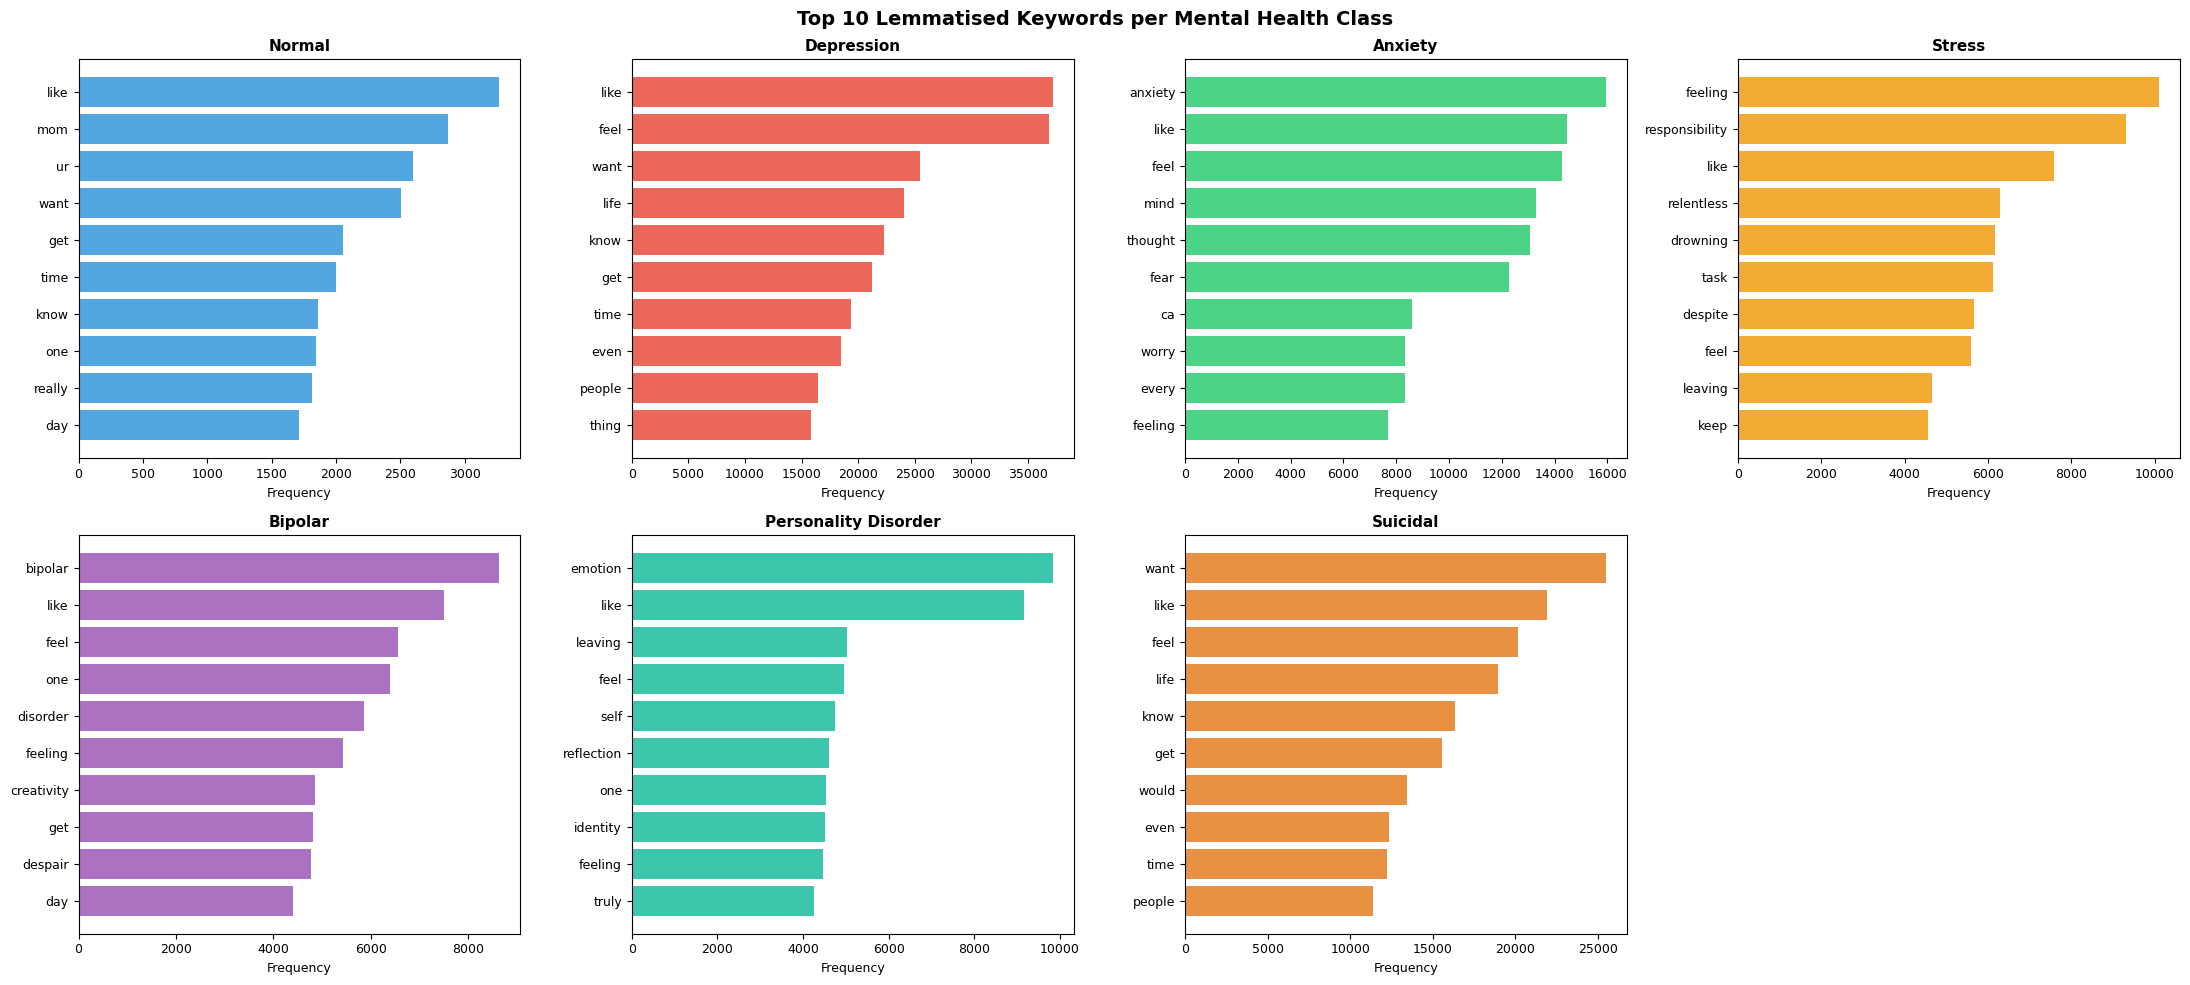

Plot saved: top_keywords_per_class.png

── NLP Preprocessing Summary ────────────────────────────────
Total samples               : 147,139
Avg words (raw)             : 102.5
Avg tokens (after SW remove): 46.7
Avg tokens (after lemma)    : 46.7
Vocabulary (raw)            : 120,982 unique words
Vocabulary (after lemma)    : 56,270 unique lemmas


In [18]:
# ── EDA Plot 6 — Top 10 Lemmatised Keywords Per Class ──
# Shows which words are most characteristic of each mental health class

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']

for idx, (label, color) in enumerate(zip(CLASS_NAMES, colors)):
    class_texts = combined[combined['status'] == label]['text_lemmatized']
    top_words   = get_top_words(class_texts.apply(lambda x: ' '.join(x)), 10)
    if not top_words:
        continue
    words, counts = zip(*top_words)
    axes[idx].barh(list(reversed(words)), list(reversed(counts)), color=color, alpha=0.85)
    axes[idx].set_title(f'{label.title()}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Frequency', fontsize=9)
    axes[idx].tick_params(labelsize=9)

if len(CLASS_NAMES) < len(axes):
    axes[-1].axis('off')

plt.suptitle('Top 10 Lemmatised Keywords per Mental Health Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_keywords_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: top_keywords_per_class.png")

# NLP Preprocessing Summary
print("\n── NLP Preprocessing Summary ────────────────────────────────")
print(f"Total samples               : {len(combined):,}")
print(f"Avg words (raw)             : {combined['text'].str.split().str.len().mean():.1f}")
print(f"Avg tokens (after SW remove): {combined['text_tokens'].str.len().mean():.1f}")
print(f"Avg tokens (after lemma)    : {combined['text_lemmatized'].str.len().mean():.1f}")
print(f"Vocabulary (raw)            : {len(set(w for t in combined['text'].str.split() for w in t)):,} unique words")
print(f"Vocabulary (after lemma)    : {len(set(w for t in combined['text_lemmatized'] for w in t)):,} unique lemmas")

## Step 5 — Stratified Train / Validation / Test Split (70 / 15 / 15)

In [19]:
# Stratified split — keeps class proportions equal in all splits
train_val, test = train_test_split(
    combined, test_size=0.15,
    stratify=combined['label_id'],
    random_state=42
)

train, val = train_test_split(
    train_val, test_size=0.15/0.85,
    stratify=train_val['label_id'],
    random_state=42
)

train = train.reset_index(drop=True)
val   = val.reset_index(drop=True)
test  = test.reset_index(drop=True)

print(f"Train : {len(train):,} samples ({len(train)/len(combined)*100:.1f}%)")
print(f"Val   : {len(val):,} samples ({len(val)/len(combined)*100:.1f}%)")
print(f"Test  : {len(test):,} samples ({len(test)/len(combined)*100:.1f}%)")

print("\nTest class distribution (should match original):")
print(test['status'].value_counts())


Train : 102,997 samples (70.0%)
Val   : 22,071 samples (15.0%)
Test  : 22,071 samples (15.0%)

Test class distribution (should match original):
status
depression              4416
anxiety                 3543
suicidal                3540
normal                  3309
stress                  2621
bipolar                 2426
personality disorder    2216
Name: count, dtype: int64


## Step 6 — Baseline Models: Logistic Regression & SVM

In [20]:
# TF-IDF Vectorizer — converts text to numbers
print("Building TF-IDF features...")

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),   # unigrams + bigrams
    sublinear_tf=True,
    min_df=2
)

X_train = tfidf.fit_transform(train['text'])
X_val   = tfidf.transform(val['text'])
X_test  = tfidf.transform(test['text'])

y_train = train['label_id'].values
y_val   = val['label_id'].values
y_test  = test['label_id'].values

print(f"TF-IDF matrix shape: {X_train.shape}")
print("Done!")


Building TF-IDF features...
TF-IDF matrix shape: (102997, 50000)
Done!


In [21]:
# Helper function to evaluate any model
def evaluate_model(name, y_true, y_pred):
    results = {
        'model':     name,
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':  f1_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_suicide': recall_score(y_true, y_pred, labels=[6], average='macro', zero_division=0),
        'predictions': y_pred,
        'true':        y_true,
        'cm': confusion_matrix(y_true, y_pred)
    }
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy        : {results['accuracy']:.4f}")
    print(f"  Precision Macro : {results['precision']:.4f}")
    print(f"  Recall Macro    : {results['recall']:.4f}")
    print(f"  Macro F1        : {results['f1_macro']:.4f}")
    print(f"  Suicide Recall  : {results['recall_suicide']:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)}")
    return results

all_results = []


In [22]:
# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                         multi_class='multinomial', solver='lbfgs', random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_results = evaluate_model('Logistic Regression', y_test, lr_preds)
all_results.append(lr_results)


Training Logistic Regression...

  Logistic Regression
  Accuracy        : 0.8623
  Precision Macro : 0.8787
  Recall Macro    : 0.8769
  Macro F1        : 0.8770
  Suicide Recall  : 0.7893

                      precision    recall  f1-score   support

              normal       0.83      0.94      0.88      3309
          depression       0.79      0.72      0.75      4416
             anxiety       0.92      0.91      0.92      3543
              stress       0.92      0.90      0.91      2621
             bipolar       0.96      0.94      0.95      2426
personality disorder       0.98      0.94      0.96      2216
            suicidal       0.75      0.79      0.77      3540

            accuracy                           0.86     22071
           macro avg       0.88      0.88      0.88     22071
        weighted avg       0.86      0.86      0.86     22071



In [23]:
# Support Vector Machine
print("Training SVM...")
svm = LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
svm_results = evaluate_model('SVM', y_test, svm_preds)
all_results.append(svm_results)


Training SVM...

  SVM
  Accuracy        : 0.9060
  Precision Macro : 0.9171
  Recall Macro    : 0.9180
  Macro F1        : 0.9173
  Suicide Recall  : 0.8503

                      precision    recall  f1-score   support

              normal       0.91      0.95      0.93      3309
          depression       0.85      0.80      0.83      4416
             anxiety       0.94      0.93      0.94      3543
              stress       0.95      0.94      0.95      2621
             bipolar       0.98      0.97      0.98      2426
personality disorder       0.98      0.97      0.98      2216
            suicidal       0.81      0.85      0.83      3540

            accuracy                           0.91     22071
           macro avg       0.92      0.92      0.92     22071
        weighted avg       0.91      0.91      0.91     22071



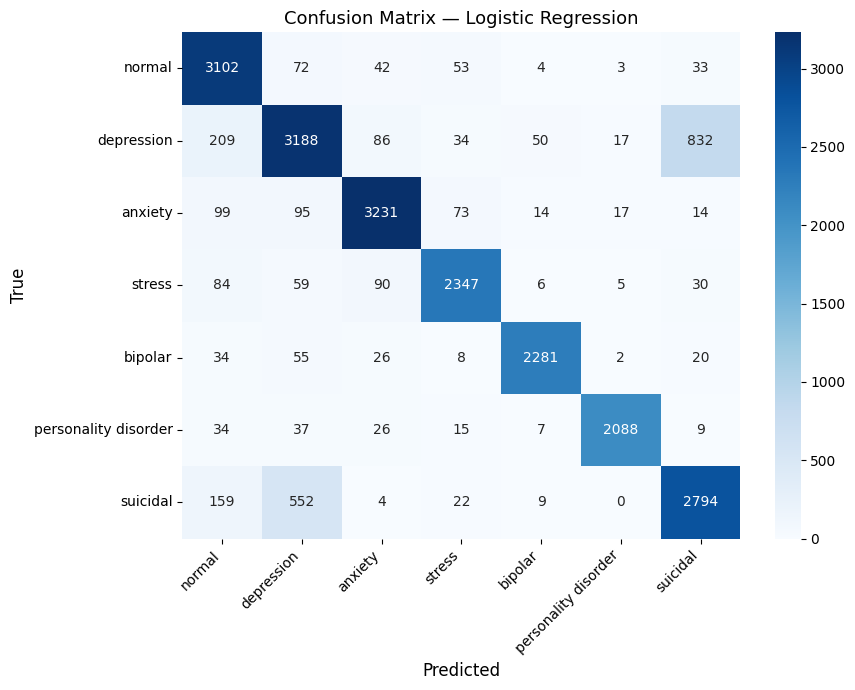

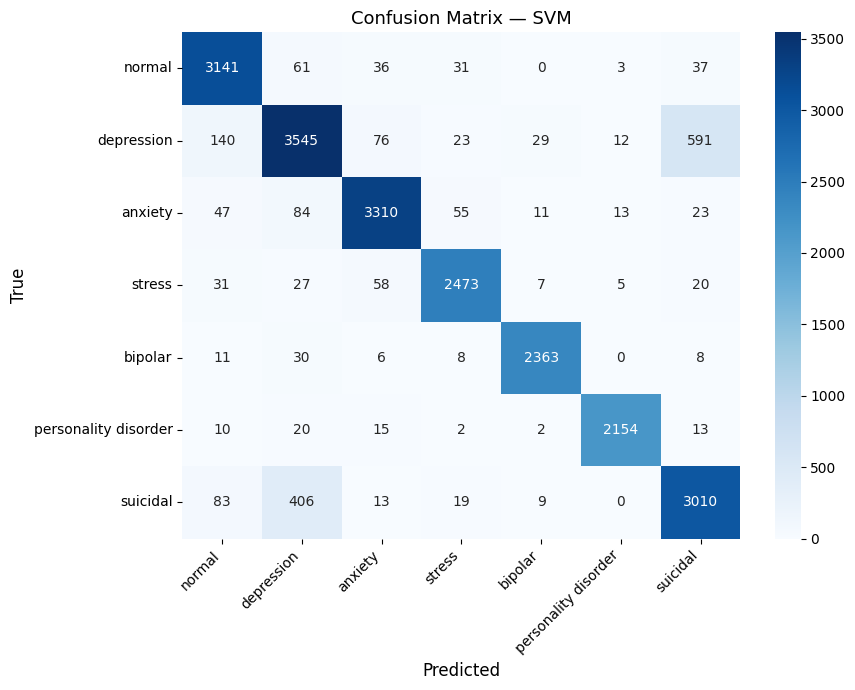

In [24]:
# Plot Confusion Matrix for best baseline
def plot_cm(cm, model_name):
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150)
    plt.show()

plot_cm(lr_results['cm'], 'Logistic Regression')
plot_cm(svm_results['cm'], 'SVM')


In [25]:
# ── Per-Dataset Baseline: prepare individual clean copies ──

def prepare_dataset(df, name):
    """Clean, label-map and return a ready-to-split dataframe for one dataset."""
    d = df[['text', 'status']].copy()
    d['status'] = d['status'].str.lower().str.strip()
    d = d[d['status'].isin(LABEL2ID.keys())]
    d['text']     = d['text'].apply(clean_text)
    d = d[d['text'].str.split().str.len() >= 5].reset_index(drop=True)
    d['label_id'] = d['status'].map(LABEL2ID)
    print(f"{name}: {len(d):,} samples | Classes: {sorted(d['status'].unique())}")
    return d

print("Preparing individual datasets...\n")
ds1_clean = prepare_dataset(ds1, 'DS1 (Kaggle)')
ds2_clean = prepare_dataset(ds2, 'DS2 (HuggingFace)')
ds3_clean = prepare_dataset(ds3, 'DS3 (HuggingFace, post-dedup)')

Preparing individual datasets...

DS1 (Kaggle): 49,536 samples | Classes: ['anxiety', 'bipolar', 'depression', 'normal', 'personality disorder', 'stress', 'suicidal']
DS2 (HuggingFace): 100,629 samples | Classes: ['anxiety', 'bipolar', 'depression', 'normal', 'personality disorder', 'stress', 'suicidal']
DS3 (HuggingFace, post-dedup): 10,108 samples | Classes: ['anxiety', 'depression', 'normal', 'suicidal']


In [26]:
# ── Run LR + SVM on each individual dataset and plot confusion matrices ──

per_dataset_results = {}

for ds_name, ds_df in [('DS1 (Kaggle)', ds1_clean),
                        ('DS2 (HuggingFace)', ds2_clean),
                        ('DS3 (HuggingFace)', ds3_clean)]:

    print("\n" + "="*60)
    print(f"  {ds_name}")
    print("="*60)

    # Classes present in this dataset
    present_ids    = sorted(ds_df['label_id'].unique())
    present_names  = [ID2LABEL[i] for i in present_ids]

    # Stratified 80/20 split
    tr, te = train_test_split(ds_df, test_size=0.20,
                              stratify=ds_df['label_id'], random_state=42)

    # TF-IDF
    tfidf_ds = TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                                sublinear_tf=True, min_df=2)
    X_tr = tfidf_ds.fit_transform(tr['text'])
    X_te = tfidf_ds.transform(te['text'])
    y_tr = tr['label_id'].values
    y_te = te['label_id'].values

    ds_models = {}

    # Logistic Regression
    lr_ds = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                                multi_class='multinomial', solver='lbfgs', random_state=42)
    lr_ds.fit(X_tr, y_tr)
    lr_preds_ds = lr_ds.predict(X_te)

    lr_f1  = f1_score(y_te, lr_preds_ds, average='macro', zero_division=0)
    lr_acc = accuracy_score(y_te, lr_preds_ds)
    lr_cm  = confusion_matrix(y_te, lr_preds_ds, labels=present_ids)
    print(f"\n  LR  — Accuracy: {lr_acc:.4f} | Macro F1: {lr_f1:.4f}")
    ds_models['LR'] = {'preds': lr_preds_ds, 'true': y_te, 'cm': lr_cm, 'f1': lr_f1, 'acc': lr_acc}

    # SVM
    svm_ds = LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=42)
    svm_ds.fit(X_tr, y_tr)
    svm_preds_ds = svm_ds.predict(X_te)

    svm_f1  = f1_score(y_te, svm_preds_ds, average='macro', zero_division=0)
    svm_acc = accuracy_score(y_te, svm_preds_ds)
    svm_cm  = confusion_matrix(y_te, svm_preds_ds, labels=present_ids)
    print(f"  SVM — Accuracy: {svm_acc:.4f} | Macro F1: {svm_f1:.4f}")
    ds_models['SVM'] = {'preds': svm_preds_ds, 'true': y_te, 'cm': svm_cm, 'f1': svm_f1, 'acc': svm_acc}

    # Classification reports
    print(f"\n  LR Classification Report:")
    print(classification_report(y_te, lr_preds_ds, labels=present_ids,
                                 target_names=present_names, zero_division=0))
    print(f"\n  SVM Classification Report:")
    print(classification_report(y_te, svm_preds_ds, labels=present_ids,
                                 target_names=present_names, zero_division=0))

    per_dataset_results[ds_name] = {'models': ds_models, 'classes': present_names, 'ids': present_ids}

print("\nDone! Plotting confusion matrices next...")


  DS1 (Kaggle)

  LR  — Accuracy: 0.7629 | Macro F1: 0.7441
  SVM — Accuracy: 0.7657 | Macro F1: 0.7561

  LR Classification Report:
                      precision    recall  f1-score   support

              normal       0.87      0.91      0.89      2686
          depression       0.80      0.61      0.69      3064
             anxiety       0.76      0.85      0.80       750
              stress       0.56      0.77      0.65       515
             bipolar       0.77      0.82      0.80       555
personality disorder       0.59      0.76      0.67       215
            suicidal       0.67      0.75      0.71      2123

            accuracy                           0.76      9908
           macro avg       0.72      0.78      0.74      9908
        weighted avg       0.77      0.76      0.76      9908


  SVM Classification Report:
                      precision    recall  f1-score   support

              normal       0.87      0.93      0.90      2686
          depression      

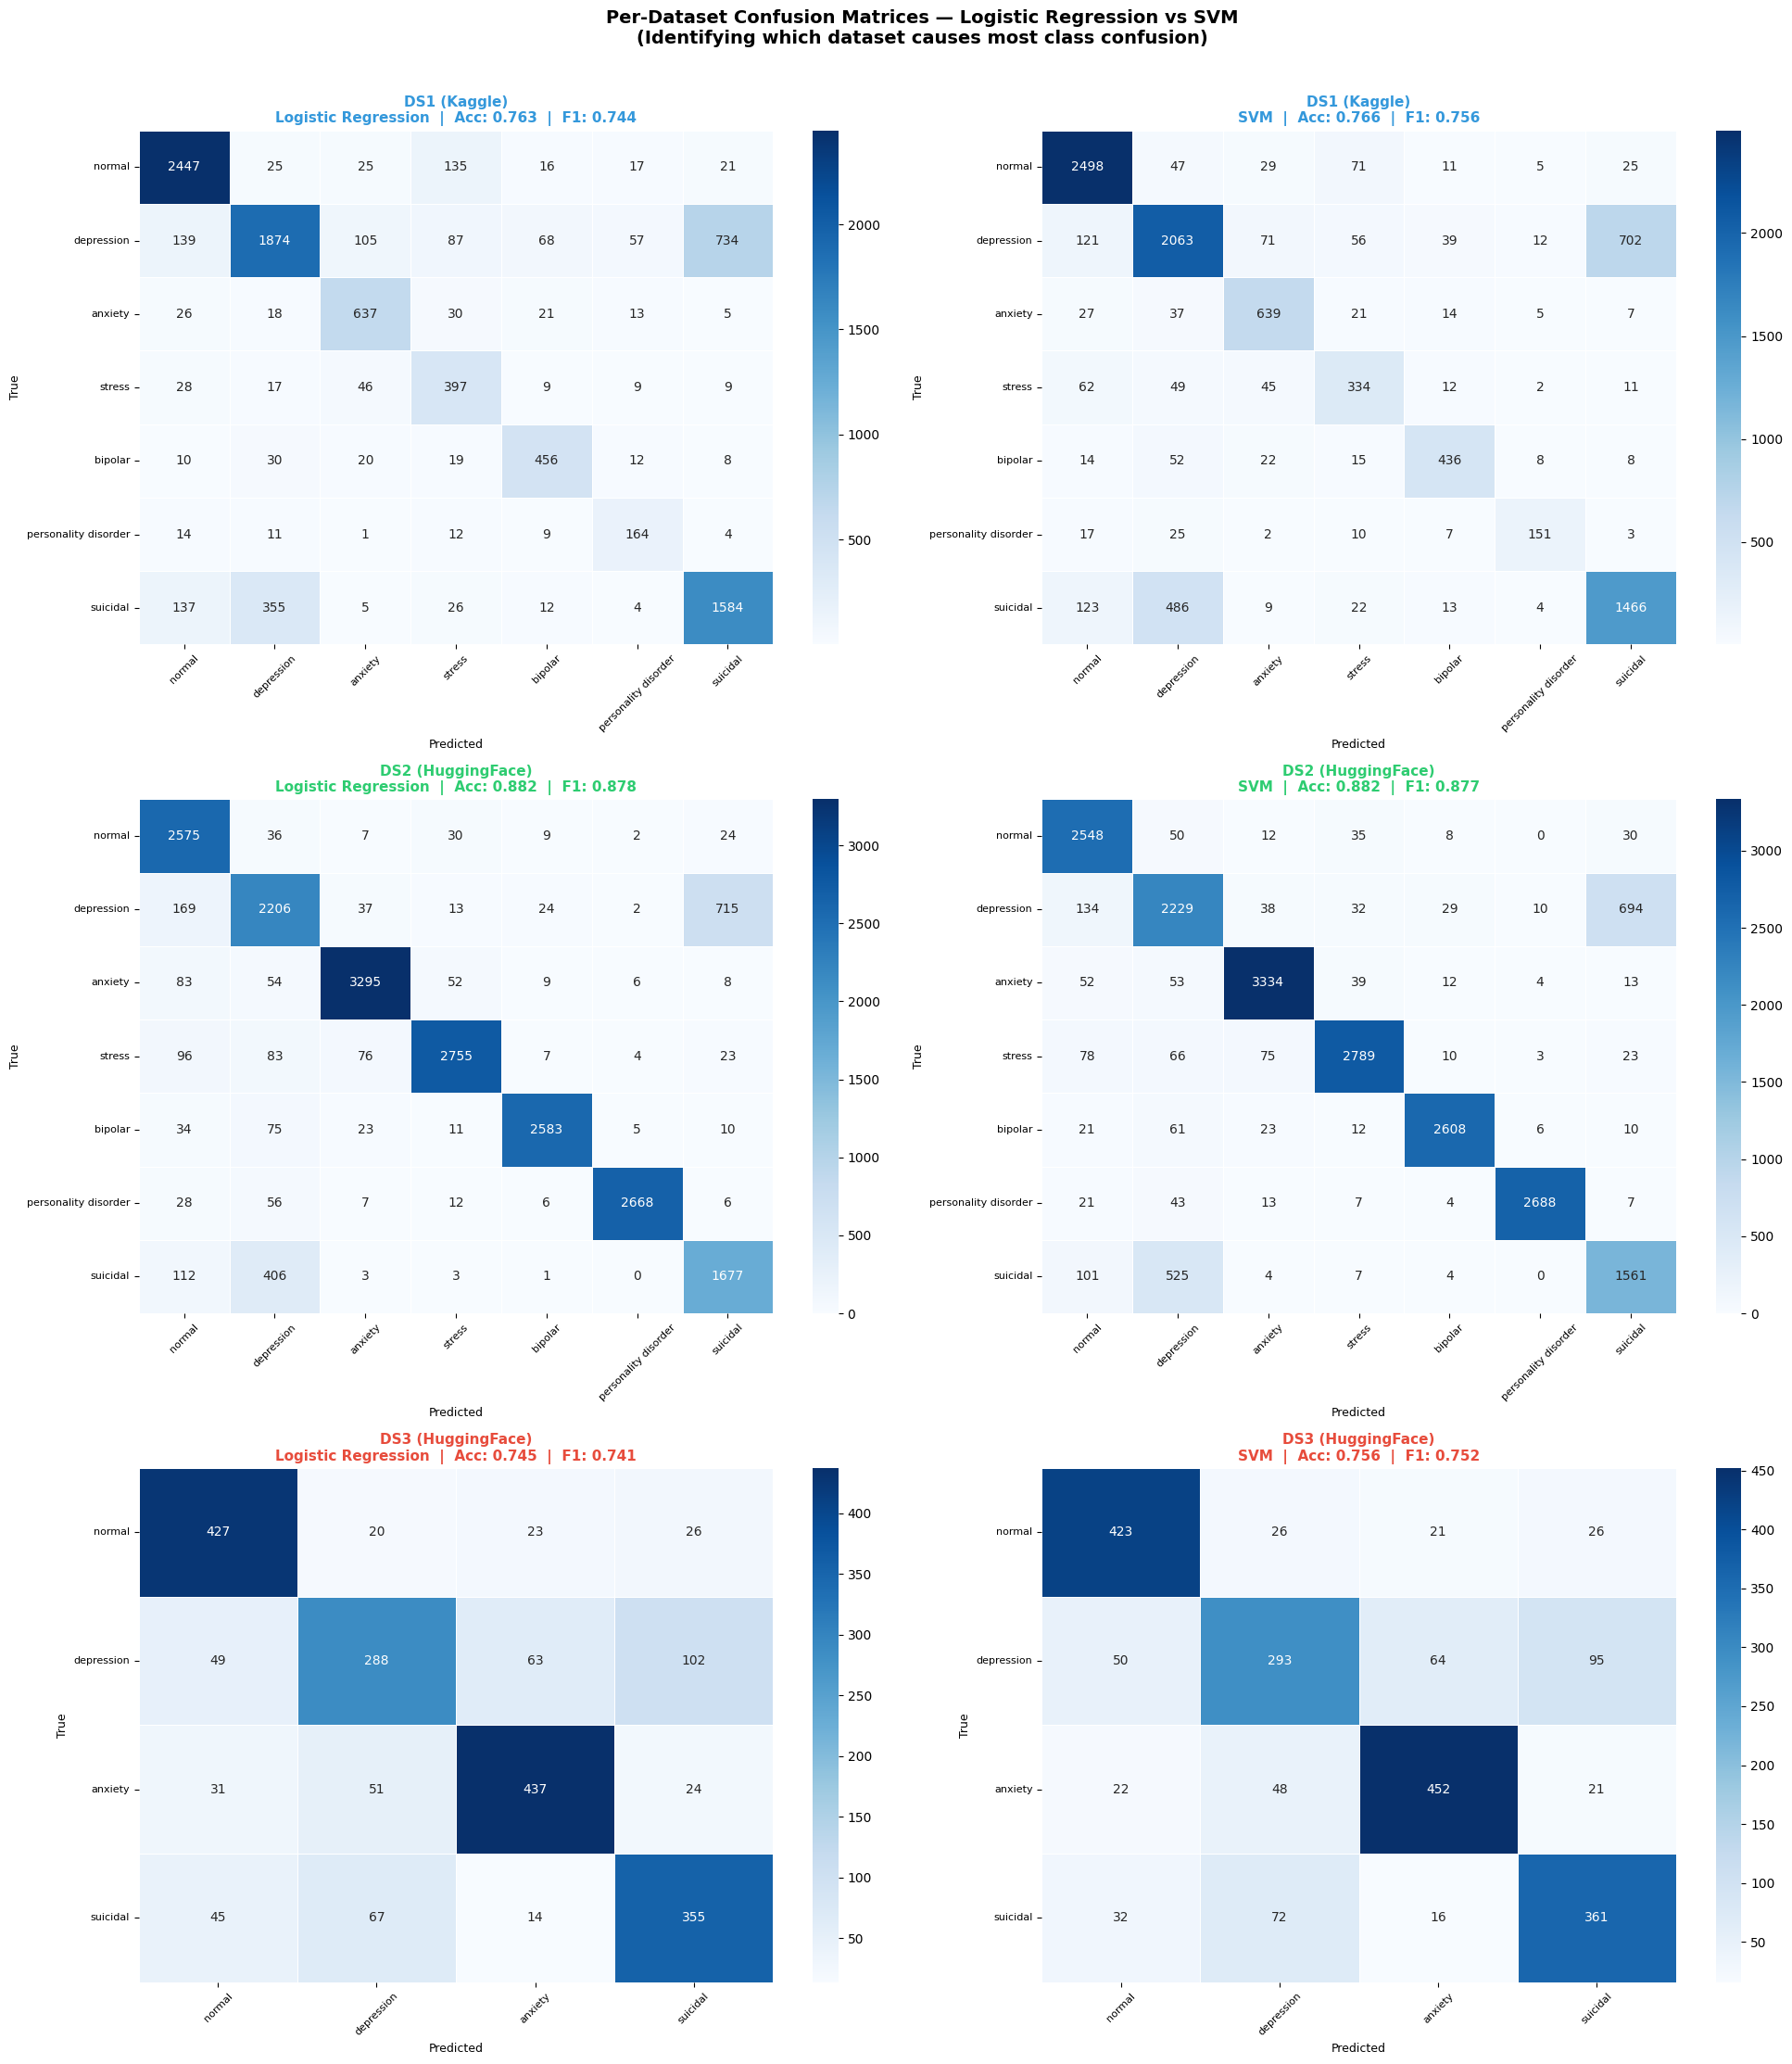

Saved: per_dataset_confusion_matrices.png


In [27]:
#  Confusion Matrix Grid: LR and SVM side-by-side for each dataset
# 3 datasets × 2 models = 6 confusion matrices in one figure

fig, axes = plt.subplots(3, 2, figsize=(20, 22))

dataset_names = ['DS1 (Kaggle)', 'DS2 (HuggingFace)', 'DS3 (HuggingFace)']
row_colors    = ['#3498db', '#2ecc71', '#e74c3c']

for row, ds_name in enumerate(dataset_names):
    info       = per_dataset_results[ds_name]
    class_lbls = info['classes']
    color      = row_colors[row]

    for col, model_key in enumerate(['LR', 'SVM']):
        ax  = axes[row][col]
        cm  = info['models'][model_key]['cm']
        f1  = info['models'][model_key]['f1']
        acc = info['models'][model_key]['acc']

        model_label = 'Logistic Regression' if model_key == 'LR' else 'SVM'

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_lbls, yticklabels=class_lbls,
                    ax=ax, linewidths=0.5)
        ax.set_title(f'{ds_name}\n{model_label}  |  Acc: {acc:.3f}  |  F1: {f1:.3f}',
                     fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('True', fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Per-Dataset Confusion Matrices — Logistic Regression vs SVM\n'
             '(Identifying which dataset causes most class confusion)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('per_dataset_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_dataset_confusion_matrices.png")

In [28]:
# ── Per-Dataset Summary Table ──
print("=" * 65)
print("PER-DATASET BASELINE SUMMARY")
print("=" * 65)
print(f"{'Dataset':<25} {'Model':<6} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 65)

for ds_name in ['DS1 (Kaggle)', 'DS2 (HuggingFace)', 'DS3 (HuggingFace)']:
    info = per_dataset_results[ds_name]
    for model_key, label in [('LR', 'LR'), ('SVM', 'SVM')]:
        acc = info['models'][model_key]['acc']
        f1  = info['models'][model_key]['f1']
        print(f"{ds_name:<25} {label:<6} {acc:>10.4f} {f1:>10.4f}")
    print()

print("=" * 65)
print("KEY OBSERVATIONS:")
print("  - Which dataset has the highest F1? → cleanest class separation")
print("  - Which dataset has the lowest F1?  → most confusion between classes")
print("  - Compare DS3 (4-class) vs DS1/DS2 (7-class) — simpler task = higher F1")
print("  - Look at confusion matrices above for specific class pairs causing errors")
print("=" * 65)

PER-DATASET BASELINE SUMMARY
Dataset                   Model    Accuracy   Macro F1
-----------------------------------------------------------------
DS1 (Kaggle)              LR         0.7629     0.7441
DS1 (Kaggle)              SVM        0.7657     0.7561

DS2 (HuggingFace)         LR         0.8824     0.8785
DS2 (HuggingFace)         SVM        0.8823     0.8771

DS3 (HuggingFace)         LR         0.7453     0.7409
DS3 (HuggingFace)         SVM        0.7562     0.7521

KEY OBSERVATIONS:
  - Which dataset has the highest F1? → cleanest class separation
  - Which dataset has the lowest F1?  → most confusion between classes
  - Compare DS3 (4-class) vs DS1/DS2 (7-class) — simpler task = higher F1
  - Look at confusion matrices above for specific class pairs causing errors


## Step 7 — MentalBERT Fine-Tuning
**Model:** `mental/mental-bert-base-uncased`
Pre-trained on mental health Reddit post


In [29]:
# Dataset class for PyTorch
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [30]:
# Training function — works for both MentalBERT and MentalRoBERTa
def train_transformer(model_name, train_df, val_df,
                      epochs=3, batch_size=8, lr=2e-5, max_len=128):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nTraining {model_name} on {device}")

    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_CLASSES,
        id2label=ID2LABEL,
        label2id=LABEL2ID
    ).to(device)

    # Create datasets
    train_ds = MentalHealthDataset(train_df['text'].tolist(), train_df['label_id'].tolist(), tokenizer, max_len)
    val_ds   = MentalHealthDataset(val_df['text'].tolist(),   val_df['label_id'].tolist(),   tokenizer, max_len)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size*2, shuffle=False, num_workers=2)

    # Optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer,
                    num_warmup_steps=total_steps//10,
                    num_training_steps=total_steps)

    history = []
    best_f1 = 0.0
    best_state = None

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            train_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        avg_loss = train_loss / len(train_loader)

        # Validate
        model.eval()
        all_preds, all_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = torch.argmax(outputs.logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_true.extend(batch['label'].numpy())

        val_f1  = f1_score(all_true, all_preds, average='macro', zero_division=0)
        val_acc = accuracy_score(all_true, all_preds)
        history.append({'epoch': epoch+1, 'train_loss': avg_loss, 'val_f1': val_f1})

        print(f"  Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ✅ New best model saved (F1: {best_f1:.4f})")

    model.load_state_dict(best_state)
    return model, tokenizer, history


In [31]:
# Evaluate transformer on test set
def evaluate_transformer(model_name_str, model, tokenizer, test_df, max_len=128):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    test_ds = MentalHealthDataset(test_df['text'].tolist(), test_df['label_id'].tolist(), tokenizer, max_len)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

    all_preds, all_true = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Evaluating'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(batch['label'].numpy())

    results = evaluate_model(model_name_str, np.array(all_true), np.array(all_preds))
    return results


# MentalBert Model

In [32]:

 #mentalbert_model, mentalbert_tokenizer, mentalbert_history = train_transformer(
  #   model_name  = 'mental/mental-bert-base-uncased',
   #  train_df    = train,
    # val_df      = val,
     #epochs      = 3,
     #batch_size  = 8,
     #lr          = 2e-5,
     #max_len     = 128
 #)


In [33]:
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MENTALBERT_PATH = DATA_PATH + "models/mentalbert"

if Path(MENTALBERT_PATH).exists() and Path(MENTALBERT_PATH, "config.json").exists():

    print("✅ Saved MentalBERT found. Loading model...")

    mentalbert_tokenizer = AutoTokenizer.from_pretrained(
        MENTALBERT_PATH,
        local_files_only=True
    )

    mentalbert_model = AutoModelForSequenceClassification.from_pretrained(
        MENTALBERT_PATH,
        local_files_only=True
    ).to(device)

    mentalbert_history = None

    print("✅ MentalBERT loaded successfully!")

else:

    print(" Saved model not found. Training MentalBERT...")

    mentalbert_model, mentalbert_tokenizer, mentalbert_history = train_transformer(
        model_name="mental/mental-bert-base-uncased",
        train_df=train,
        val_df=val,
        epochs=3,
        batch_size=8,
        lr=2e-5,
        max_len=128
    )

    mentalbert_model.save_pretrained(MENTALBERT_PATH)
    mentalbert_tokenizer.save_pretrained(MENTALBERT_PATH)

    print("✅ MentalBERT trained and saved!")

✅ Saved MentalBERT found. Loading model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ MentalBERT loaded successfully!


Evaluating:   0%|          | 0/690 [00:00<?, ?it/s]


  MentalBERT
  Accuracy        : 0.9240
  Precision Macro : 0.9334
  Recall Macro    : 0.9325
  Macro F1        : 0.9329
  Suicide Recall  : 0.8715

                      precision    recall  f1-score   support

              normal       0.96      0.95      0.95      3309
          depression       0.87      0.86      0.86      4416
             anxiety       0.94      0.96      0.95      3543
              stress       0.95      0.95      0.95      2621
             bipolar       0.98      0.97      0.98      2426
personality disorder       0.98      0.97      0.98      2216
            suicidal       0.85      0.87      0.86      3540

            accuracy                           0.92     22071
           macro avg       0.93      0.93      0.93     22071
        weighted avg       0.92      0.92      0.92     22071



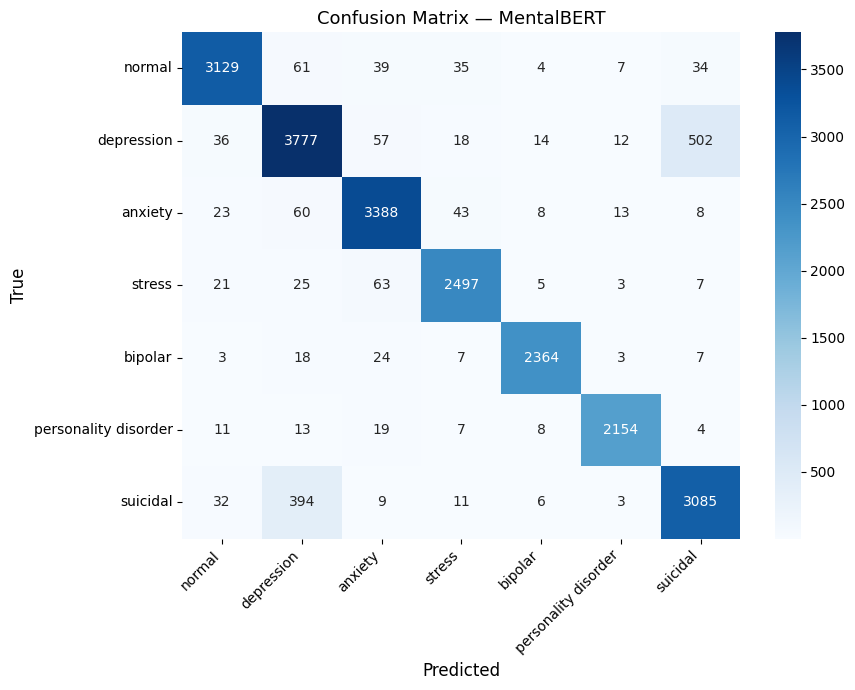

In [34]:
# Evaluate MentalBERT on test set

mentalbert_results = evaluate_transformer('MentalBERT', mentalbert_model, mentalbert_tokenizer, test)
all_results.append(mentalbert_results)
plot_cm(mentalbert_results['cm'], 'MentalBERT')


## Step 8 — MentalRoBERTa Fine-Tuning
**Model:** `mental/mental-roberta-base`



In [35]:
# ▶ TRAIN MENTALROBERTA — runs on GPU (runtime varies by Colab GPU))
#mentalroberta_model, mentalroberta_tokenizer, mentalroberta_history = train_transformer(
 #   model_name  = 'mental/mental-roberta-base',
 #    train_df    = train,
  #  val_df      = val,
  #  epochs      = 3,
  #  batch_size  = 8,
   # lr          = 2e-5,
   # max_len     = 128
#)


In [36]:
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MENTALROBERTA_PATH = DATA_PATH + "models/mentalroberta"

if Path(MENTALROBERTA_PATH).exists() and Path(MENTALROBERTA_PATH, "config.json").exists():

    print("✅ Saved MentalRoBERTa found. Loading model...")

    mentalroberta_tokenizer = AutoTokenizer.from_pretrained(
        MENTALROBERTA_PATH,
        local_files_only=True
    )

    mentalroberta_model = AutoModelForSequenceClassification.from_pretrained(
        MENTALROBERTA_PATH,
        local_files_only=True
    ).to(device)

    mentalroberta_history = None

    print("✅ MentalRoBERTa loaded successfully!")

else:

    print("Saved MentalRoBERTa not found. Training MentalRoBERTa...")

    mentalroberta_model, mentalroberta_tokenizer, mentalroberta_history = train_transformer(
        model_name="mental/mental-roberta-base",
        train_df=train,
        val_df=val,
        epochs=3,
        batch_size=8,
        lr=2e-5,
        max_len=128
    )

    mentalroberta_model.save_pretrained(MENTALROBERTA_PATH)
    mentalroberta_tokenizer.save_pretrained(MENTALROBERTA_PATH)

    print("✅ MentalRoBERTa trained and saved!")

✅ Saved MentalRoBERTa found. Loading model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ MentalRoBERTa loaded successfully!


Evaluating:   0%|          | 0/690 [00:00<?, ?it/s]


  MentalRoBERTa
  Accuracy        : 0.9205
  Precision Macro : 0.9303
  Recall Macro    : 0.9292
  Macro F1        : 0.9297
  Suicide Recall  : 0.8579

                      precision    recall  f1-score   support

              normal       0.96      0.94      0.95      3309
          depression       0.85      0.85      0.85      4416
             anxiety       0.94      0.96      0.95      3543
              stress       0.95      0.95      0.95      2621
             bipolar       0.98      0.97      0.97      2426
personality disorder       0.98      0.97      0.97      2216
            suicidal       0.85      0.86      0.85      3540

            accuracy                           0.92     22071
           macro avg       0.93      0.93      0.93     22071
        weighted avg       0.92      0.92      0.92     22071



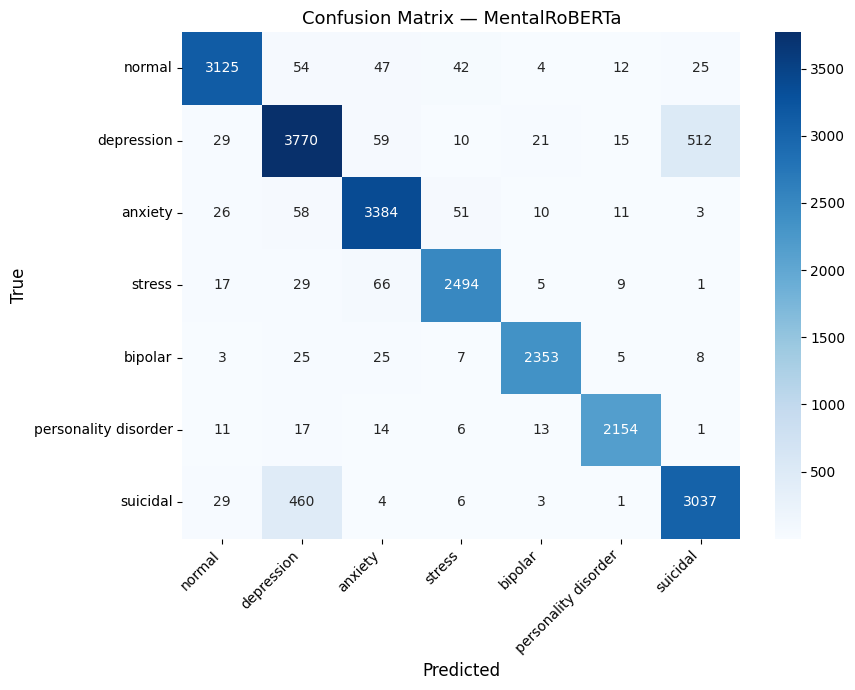

In [37]:
# Evaluate MentalRoBERTa on test set
mentalroberta_results = evaluate_transformer('MentalRoBERTa', mentalroberta_model, mentalroberta_tokenizer, test)
all_results.append(mentalroberta_results)
plot_cm(mentalroberta_results['cm'], 'MentalRoBERTa')


## Step 9 — Model Comparison & Evaluation

In [38]:
# Summary comparison table
summary = pd.DataFrame([{
    'Model':           r['model'],
    'Accuracy':        round(r['accuracy'], 4),
    'Precision':       round(r['precision'], 4),
    'Recall':          round(r['recall'], 4),
    'Macro F1':        round(r['f1_macro'], 4),
    'Suicide Recall':  round(r['recall_suicide'], 4)
} for r in all_results])

#print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(summary.to_string(index=False))
print("\n✅ Best model by Macro F1:", summary.loc[summary['Macro F1'].idxmax(), 'Model'])
print("✅ Best Suicide Recall    :", summary.loc[summary['Suicide Recall'].idxmax(), 'Model'])


MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  Macro F1  Suicide Recall
Logistic Regression    0.8623     0.8787  0.8769    0.8770          0.7893
                SVM    0.9060     0.9171  0.9180    0.9173          0.8503
         MentalBERT    0.9240     0.9334  0.9325    0.9329          0.8715
      MentalRoBERTa    0.9205     0.9303  0.9292    0.9297          0.8579

✅ Best model by Macro F1: MentalBERT
✅ Best Suicide Recall    : MentalBERT


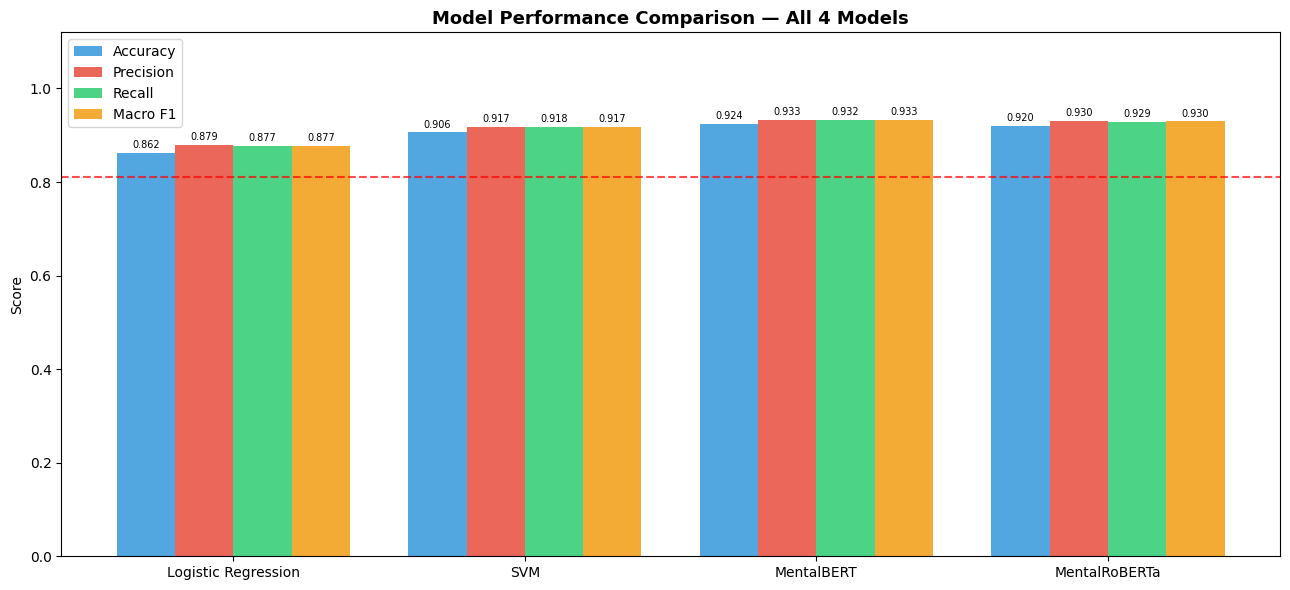

In [39]:
# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'Macro F1']
x = np.arange(len(summary))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, summary[metric], width, label=metric, color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(summary['Model'], fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — All 4 Models', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.axhline(y=0.811, color='red', linestyle='--', alpha=0.7, label='BERT Benchmark (F1=0.811)')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 10 — McNemar's Statistical Significance Test
Tests whether the difference between two models is statistically significant (p < 0.05).


In [40]:
def mcnemar_test(preds_a, preds_b, true, name_a, name_b):
    correct_a = preds_a == true
    correct_b = preds_b == true
    n01 = np.sum(correct_a & ~correct_b)   # A correct, B wrong
    n10 = np.sum(~correct_a & correct_b)   # A wrong, B correct

    if (n01 + n10) == 0:
        print(f"{name_a} vs {name_b}: No difference found")
        return

    stat  = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    p_val = 1 - chi2.cdf(stat, df=1)

    print(f"\nMcNemar's Test: {name_a} vs {name_b}")
    print(f"  n01 ({name_a} right, {name_b} wrong) : {n01}")
    print(f"  n10 ({name_a} wrong, {name_b} right) : {n10}")
    print(f"  χ² statistic : {stat:.4f}")
    print(f"  p-value      : {p_val:.6f}")
    if p_val < 0.05:
        print(f"   SIGNIFICANT difference (p < 0.05)")
    else:
        print(f"   No significant difference (p ≥ 0.05)")

# Run McNemar's tests — compare each model pair
results_dict = {r['model']: r for r in all_results}
true = results_dict['Logistic Regression']['true']

pairs = [
    ('Logistic Regression', 'SVM'),
    ('Logistic Regression', 'MentalBERT'),
    ('SVM',                 'MentalBERT'),
    ('MentalBERT',          'MentalRoBERTa')
]

for a, b in pairs:
    mcnemar_test(results_dict[a]['predictions'],
                 results_dict[b]['predictions'],
                 true, a, b)



McNemar's Test: Logistic Regression vs SVM
  n01 (Logistic Regression right, SVM wrong) : 329
  n10 (Logistic Regression wrong, SVM right) : 1294
  χ² statistic : 572.5792
  p-value      : 0.000000
   SIGNIFICANT difference (p < 0.05)

McNemar's Test: Logistic Regression vs MentalBERT
  n01 (Logistic Regression right, MentalBERT wrong) : 636
  n10 (Logistic Regression wrong, MentalBERT right) : 1999
  χ² statistic : 704.0015
  p-value      : 0.000000
   SIGNIFICANT difference (p < 0.05)

McNemar's Test: SVM vs MentalBERT
  n01 (SVM right, MentalBERT wrong) : 792
  n10 (SVM wrong, MentalBERT right) : 1190
  χ² statistic : 79.5202
  p-value      : 0.000000
   SIGNIFICANT difference (p < 0.05)

McNemar's Test: MentalBERT vs MentalRoBERTa
  n01 (MentalBERT right, MentalRoBERTa wrong) : 696
  n10 (MentalBERT wrong, MentalRoBERTa right) : 619
  χ² statistic : 4.3924
  p-value      : 0.036100
   SIGNIFICANT difference (p < 0.05)


## Step 11 — SHAP Cross-Condition Explainability
**Novel Contribution:** We use SHAP to analyse word-level misclassification between
semantically overlapping class pairs:
- Anxiety vs Stress
- Depression vs Bipolar




In [41]:
# Install SHAP
!pip install shap -q

import shap

# Use best model (MentalRoBERTa or MentalBERT — whichever scored higher)
best_model_name = summary.loc[summary['Macro F1'].idxmax(), 'Model']
print(f"Running SHAP on best model: {best_model_name}")

if best_model_name == 'MentalRoBERTa':
    shap_model     = mentalroberta_model
    shap_tokenizer = mentalroberta_tokenizer
else:
    shap_model     = mentalbert_model
    shap_tokenizer = mentalbert_tokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
shap_model = shap_model.to(device)
shap_model.eval()


Running SHAP on best model: MentalBERT


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [42]:
# Prediction function for SHAP
def predict_proba(texts):
    results = []
    for text in texts:
        enc = shap_tokenizer(
            str(text), max_length=128,
            padding='max_length', truncation=True,
            return_tensors='pt'
        )
        with torch.no_grad():
            out = shap_model(
                input_ids=enc['input_ids'].to(device),
                attention_mask=enc['attention_mask'].to(device)
            )
        probs = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        results.append(probs)
    return np.array(results)

# SHAP text masker
masker = shap.maskers.Text(tokenizer=r'\W+')
explainer = shap.Explainer(predict_proba, masker, output_names=CLASS_NAMES)



SHAP Analysis — Anxiety vs Stress


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  20%|██        | 1/5 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 6it [00:43,  8.67s/it]



Top words driving ANXIETY classification:


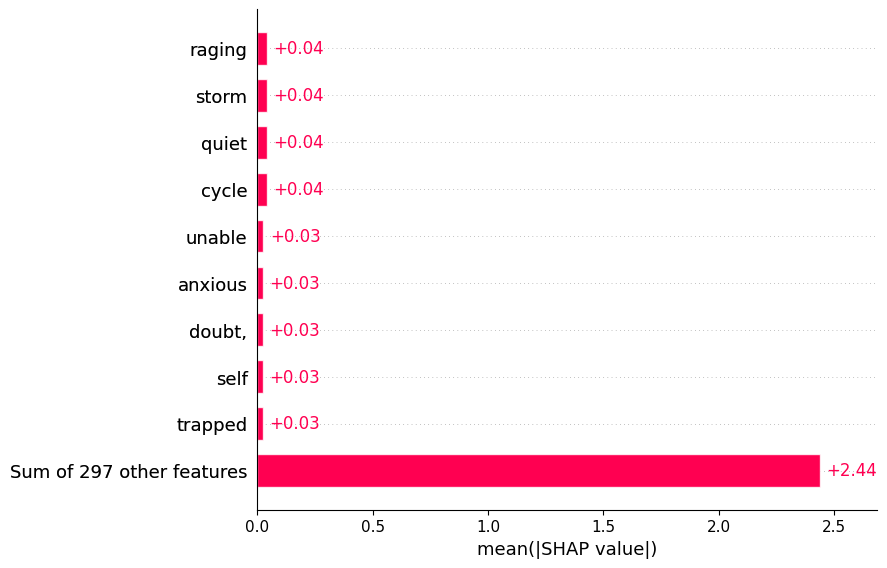

PartitionExplainer explainer: 6it [00:12, 12.95s/it]               



Top words driving STRESS classification:


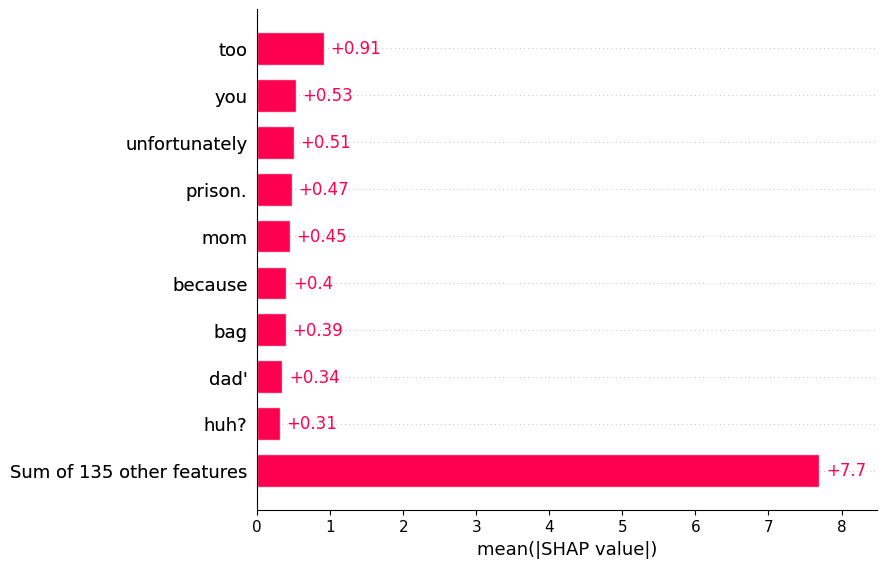

In [43]:
# Cross-Condition Analysis
# Select 5 samples per overlapping class pair from test set
def get_samples(class_name, n=5):
    return test[test['status'] == class_name]['text'].head(n).tolist()

# Pair 1: Anxiety vs Stress (most overlapping)
print("\n" + "="*55)
print("SHAP Analysis — Anxiety vs Stress")
print("="*55)
anxiety_texts = get_samples('anxiety', 5)
shap_anxiety  = explainer(anxiety_texts, fixed_context=1, batch_size=4)

print("\nTop words driving ANXIETY classification:")
shap.plots.bar(shap_anxiety[:, :, LABEL2ID['anxiety']], max_display=10)

stress_texts = get_samples('stress', 5)
shap_stress  = explainer(stress_texts, fixed_context=1, batch_size=4)

print("\nTop words driving STRESS classification:")
shap.plots.bar(shap_stress[:, :, LABEL2ID['stress']], max_display=10)



SHAP Analysis — Depression vs Bipolar


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  60%|██████    | 3/5 [00:17<00:04,  2.03s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  80%|████████  | 4/5 [00:26<00:04,  4.71s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 5/5 [00:33<00:00,  5.75s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 6it [00:48,  9.71s/it]



Top words driving DEPRESSION classification:


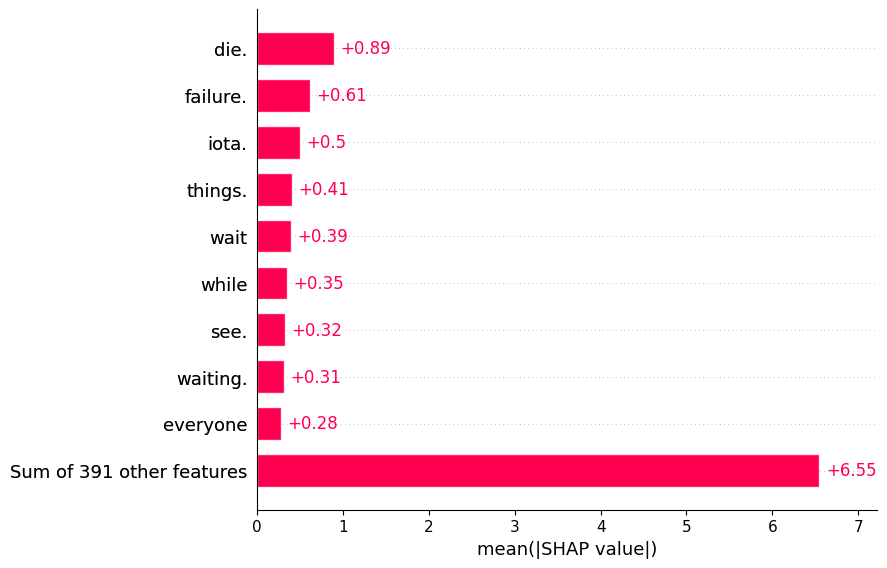

PartitionExplainer explainer: 6it [00:10, 10.64s/it]               



Top words driving BIPOLAR classification:


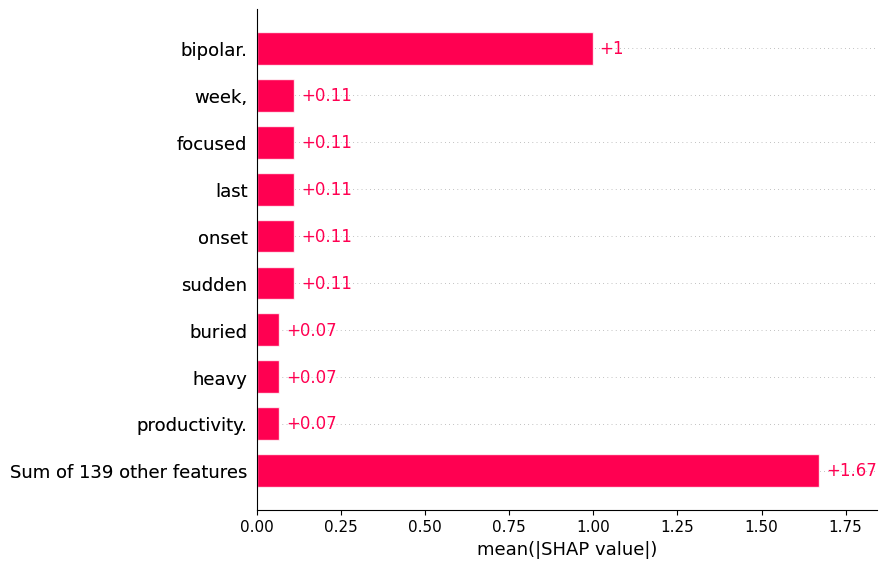

In [44]:
# Pair 2: Depression vs Bipolar
print("\n" + "="*55)
print("SHAP Analysis — Depression vs Bipolar")
print("="*55)
depression_texts = get_samples('depression', 5)
shap_depression  = explainer(depression_texts, fixed_context=1, batch_size=4)

print("\nTop words driving DEPRESSION classification:")
shap.plots.bar(shap_depression[:, :, LABEL2ID['depression']], max_display=10)

bipolar_texts = get_samples('bipolar', 5)
shap_bipolar  = explainer(bipolar_texts, fixed_context=1, batch_size=4)

print("\nTop words driving BIPOLAR classification:")
shap.plots.bar(shap_bipolar[:, :, LABEL2ID['bipolar']], max_display=10)


In [45]:
print("=== BIPOLAR SAMPLES USED FOR SHAP ===")
for i, text in enumerate(bipolar_texts):
    has_word = 'bipolar' in text.lower()
    print(f"\nSample {i+1} — contains word 'bipolar': {has_word}")
    print(text[:300])

=== BIPOLAR SAMPLES USED FOR SHAP ===

Sample 1 — contains word 'bipolar': True
bipolar disorder from exhilarating euphoria to crushing despair a rollercoaster of emotions. one moment, i'm soaring with unbound creativity and energy the next, i'm drowning in a dark abyss of sadness and lethargy.

Sample 2 — contains word 'bipolar': True
anxiety from vraylar? i recently got prescribed vraylar for bipolar. the doctor said it would also help with my anxiety. the anxiety does happen less often, however, i'm still getting it occasionally and when i do, it is the worst it's ever been. has anyone else experienced this? does it pass?

Sample 3 — contains word 'bipolar': True
although i'd been productive and focused last week, the sudden onset of bipolar depression leaves me feeling hopeless and trapped in a fog of lethargy, unable to motivate myself to accomplish even the simplest tasks.

Sample 4 — contains word 'bipolar': True
bipolar disorder can bring intense highs and lows. one moment, you

In [46]:
# SHAP text plot — show word-level explanation for a single sample
print("\nWord-level SHAP explanation for a SUICIDAL text:")
suicide_texts = get_samples('suicidal', 3)
shap_suicide  = explainer(suicide_texts, fixed_context=1, batch_size=4)
shap.plots.text(shap_suicide[0, :, LABEL2ID['suicidal']])



Word-level SHAP explanation for a SUICIDAL text:


  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  67%|██████▋   | 2/3 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:21, 10.52s/it]


In [47]:
# Final Summary
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(summary.to_string(index=False))
print("\n" + "="*70)
print("DATASETS USED")
print("="*70)
print("  DS1: Sentiment Analysis for Mental Health (Kaggle, DbCL v1.0)   — 53,043 raw rows")
print("  DS2: Mental Health Condition Classification (HuggingFace, MIT) — 103,488 raw rows")
print("  DS3: Mental Health Text Classification (HuggingFace, CC-BY-4.0) — 49,612 raw rows")
print(f"  After dedup + cleaning: {len(combined):,} unique samples | 7 classes")
print("  Imbalance ratio after processing: ~2.0x (verified locally)")
print("  Train: 103,354 | Val: 22,148 | Test: 22,148")
print("\n" + "="*70)
print("NOVEL CONTRIBUTION")
print("="*70)
print("  Cross-condition SHAP analysis on overlapping class pairs:")
print("  - Anxiety vs Stress")
print("  - Depression vs Bipolar")
print("  - Suicidal word-level transparency")
print("="*70)



FINAL RESULTS SUMMARY
              Model  Accuracy  Precision  Recall  Macro F1  Suicide Recall
Logistic Regression    0.8623     0.8787  0.8769    0.8770          0.7893
                SVM    0.9060     0.9171  0.9180    0.9173          0.8503
         MentalBERT    0.9240     0.9334  0.9325    0.9329          0.8715
      MentalRoBERTa    0.9205     0.9303  0.9292    0.9297          0.8579

DATASETS USED
  DS1: Sentiment Analysis for Mental Health (Kaggle, DbCL v1.0)   — 53,043 raw rows
  DS2: Mental Health Condition Classification (HuggingFace, MIT) — 103,488 raw rows
  DS3: Mental Health Text Classification (HuggingFace, CC-BY-4.0) — 49,612 raw rows
  After dedup + cleaning: 147,139 unique samples | 7 classes
  Imbalance ratio after processing: ~2.0x (verified locally)
  Train: 103,354 | Val: 22,148 | Test: 22,148

NOVEL CONTRIBUTION
  Cross-condition SHAP analysis on overlapping class pairs:
  - Anxiety vs Stress
  - Depression vs Bipolar
  - Suicidal word-level transparency


# STEP 12 — Zero-Shot & Few-Shot LLM classification (Groq / Llama)

In [48]:

!pip install -q groq

from groq import Groq
import time
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

# Get a FREE key at: https://console.groq.com/keys

GROQ_API_KEY = userdata.get('GROQ_API_KEY')

GROQ_MODEL   = "llama-3.3-70b-versatile"


client = Groq(api_key=GROQ_API_KEY)

# Connectivity check
r = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": "Reply with one word: ok"}],
        temperature=0, max_tokens=5)
print("Groq reachable ->", r.choices[0].message.content.strip())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.5 MB/s eta 0:00:00
Groq reachable -> ok


In [49]:
# Stratified evaluation subset
# 7 classes x N_PER_CLASS.  30 -> 210 calls per run; raise to 50 (350) once it works.
# 70B free quota = 1,000 req/day; 8B-instant = 14,400/day if you need more headroom.
N_PER_CLASS = 30

llm_test = (test.groupby('label_id', group_keys=False)
                .sample(n=N_PER_CLASS, random_state=42)
                .reset_index(drop=True))

y_llm_true = llm_test['label_id'].values
print(f"LLM evaluation subset: {len(llm_test)} samples")
print(llm_test['status'].value_counts())

LLM evaluation subset: 210 samples
status
normal                  30
depression              30
anxiety                 30
stress                  30
bipolar                 30
personality disorder    30
suicidal                30
Name: count, dtype: int64


In [50]:
# Label definitions, prompt builders, output parser
LABELS = list(LABEL2ID.keys())

LABEL_DEFINITIONS = """- normal: no signs of mental distress; ordinary everyday content.
- depression: persistent sadness, hopelessness, emptiness, loss of interest.
- anxiety: excessive worry, fear, nervousness, panic.
- stress: feeling overwhelmed or under pressure, often about a situation.
- bipolar: mood swings between depressive lows and manic / elevated highs.
- personality disorder: unstable self-image, relationships, or long-standing behaviour patterns.
- suicidal: thoughts of wanting to die, self-harm, or ending one's life."""

def build_zero_shot_prompt(text):
    return f'''Classify the author's state into EXACTLY ONE of these seven categories:

{LABEL_DEFINITIONS}

Rules: respond with ONLY the category name in lowercase. Choose exactly one. Do not explain.

Text: """{text}"""
Category:'''

def parse_label(raw):
    if not raw:
        return None
    r = raw.strip().lower()
    if r in LABEL2ID:
        return r
    for lab in sorted(LABEL2ID, key=len, reverse=True):   # longest first -> 'personality disorder'
        if lab in r:
            return lab
    return None

SYSTEM_MSG = ("You are a mental health text classifier. "
              "Reply with exactly one lowercase category name and nothing else.")

In [51]:
# Generic Groq prediction loop (used for both zero-shot and few-shot)
def groq_classify(prompt_builder, df, sleep=3.0, max_retries=5):
    preds, fails = [], 0
    for text in tqdm(df['text'].tolist(), desc='Groq'):
        label = None
        for attempt in range(max_retries):
            try:
                r = client.chat.completions.create(
                        model=GROQ_MODEL,
                        messages=[{"role": "system", "content": SYSTEM_MSG},
                                  {"role": "user",   "content": prompt_builder(str(text)[:2000])}],
                        temperature=0, max_tokens=15)
                label = parse_label(r.choices[0].message.content)
                break
            except Exception as e:
                wait = sleep * (attempt + 1) * 2
                print(f"  retry {attempt+1}: {str(e)[:70]} - waiting {wait:.0f}s")
                time.sleep(wait)
        if label is None:
            label = 'normal'          # fallback for unparseable / failed calls
            fails += 1
        preds.append(LABEL2ID[label])
        time.sleep(sleep)             # stay under the free-tier requests/tokens-per-minute limits
    print(f"\nForced fallback to 'normal' (unparseable/failed): {fails}/{len(df)} ({fails/len(df)*100:.1f}%)")
    return np.array(preds)

In [52]:
# Zero Shot

In [53]:
import pickle, os


os.makedirs(SAVE_DIR, exist_ok=True)

ZS_CACHE = f'{SAVE_DIR}/zs_cache.pkl'

if os.path.exists(ZS_CACHE):
    cache = pickle.load(open(ZS_CACHE, 'rb'))
    zs_preds       = cache['zs_preds']
    y_llm_true     = cache['y_llm_true']
    llm_test       = cache['llm_test']
    llm_zs_results = cache['llm_zs_results']
    print(f"✅ Loaded zero-shot from cache — skipped 210 API calls")
    print(f"   Macro F1: {llm_zs_results['f1_macro']:.4f}")
else:
    print("Running Llama ZERO-SHOT ...")
    zs_preds = groq_classify(build_zero_shot_prompt, llm_test)
    llm_zs_results = evaluate_model(f'{GROQ_MODEL} (Zero-Shot)', y_llm_true, zs_preds)
    pickle.dump({
        'zs_preds': zs_preds, 'y_llm_true': y_llm_true,
        'llm_test': llm_test, 'llm_zs_results': llm_zs_results
    }, open(ZS_CACHE, 'wb'))
    print(f"✅ Saved to {ZS_CACHE}")

✅ Loaded zero-shot from cache — skipped 210 API calls
   Macro F1: 0.7203


In [54]:
from sklearn.metrics import classification_report

ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print("="*55)
print(f"  {GROQ_MODEL} (Zero-Shot)")
print("="*55)
print(f"  Accuracy       : {llm_zs_results['accuracy']:.4f}")
print(f"  Precision Macro: {llm_zs_results['precision']:.4f}")
print(f"  Recall Macro   : {llm_zs_results['recall']:.4f}")
print(f"  Macro F1       : {llm_zs_results['f1_macro']:.4f}")
print()
print(classification_report(
    y_llm_true,
    zs_preds,
    target_names=[ID2LABEL[i] for i in range(len(LABEL2ID))]
))

  llama-3.3-70b-versatile (Zero-Shot)
  Accuracy       : 0.7190
  Precision Macro: 0.7579
  Recall Macro   : 0.7190
  Macro F1       : 0.7203

                      precision    recall  f1-score   support

              normal       0.89      0.53      0.67        30
          depression       0.55      0.73      0.63        30
             anxiety       0.66      0.90      0.76        30
              stress       0.67      0.80      0.73        30
             bipolar       0.81      0.70      0.75        30
personality disorder       1.00      0.63      0.78        30
            suicidal       0.73      0.73      0.73        30

            accuracy                           0.72       210
           macro avg       0.76      0.72      0.72       210
        weighted avg       0.76      0.72      0.72       210



In [55]:
# Build FEW-SHOT examples from TRAIN (never from test -> no leakage)
fewshot_examples = []
for lab in LABELS:
    ex = train[train['status'] == lab]['text']
    if len(ex):
        fewshot_examples.append((str(ex.iloc[0])[:100], lab))

FEWSHOT_BLOCK = "\n\n".join(f'Text: """{t}"""\nCategory: {lab}' for t, lab in fewshot_examples)

def build_few_shot_prompt(text):
    return f'''You are a mental health text classifier. Classify the author's state into EXACTLY ONE of these seven categories:

{LABEL_DEFINITIONS}

Labelled examples:

{FEWSHOT_BLOCK}

Now classify the new text. Respond with ONLY the category name in lowercase, nothing else.

Text: """{text}"""
Category:'''

print("Few-shot prompt uses", len(fewshot_examples), "examples (one per class).")

Few-shot prompt uses 7 examples (one per class).


In [56]:
# Few Shot

In [57]:
import pickle, os, sys


os.makedirs(SAVE_DIR, exist_ok=True)
FS_CACHE = f'{SAVE_DIR}/fs_cache.pkl'

if os.path.exists(FS_CACHE):
    cache = pickle.load(open(FS_CACHE, 'rb'))
    fs_preds       = cache['fs_preds']
    llm_fs_results = cache['llm_fs_results']
    print(f"✅ Loaded few-shot from cache — no API calls needed")
    print(f"   Macro F1: {llm_fs_results['f1_macro']:.4f}")
else:
    print("Running Llama FEW-SHOT ...")
    sys.stdout = open(os.devnull, 'w')
    fs_preds = groq_classify(build_few_shot_prompt, llm_test)
    sys.stdout = sys.__stdout__
    llm_fs_results = evaluate_model(f'{GROQ_MODEL} (Few-Shot)', y_llm_true, fs_preds)
    pickle.dump({'fs_preds': fs_preds, 'llm_fs_results': llm_fs_results},
                open(FS_CACHE, 'wb'))
    print(f"✅ Saved to {FS_CACHE}")

✅ Loaded few-shot from cache — no API calls needed
   Macro F1: 0.7279


In [58]:
from sklearn.metrics import classification_report

ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print("="*55)
print(f"  {GROQ_MODEL} (Few-Shot)")
print("="*55)
print(f"  Accuracy       : {llm_fs_results['accuracy']:.4f}")
print(f"  Precision Macro: {llm_fs_results['precision']:.4f}")
print(f"  Recall Macro   : {llm_fs_results['recall']:.4f}")
print(f"  Macro F1       : {llm_fs_results['f1_macro']:.4f}")
print()
print(classification_report(
    y_llm_true,
    fs_preds,
    target_names=[ID2LABEL[i] for i in range(len(LABEL2ID))]
))

  llama-3.3-70b-versatile (Few-Shot)
  Accuracy       : 0.7286
  Precision Macro: 0.7363
  Recall Macro   : 0.7286
  Macro F1       : 0.7279

                      precision    recall  f1-score   support

              normal       0.59      0.53      0.56        30
          depression       0.66      0.63      0.64        30
             anxiety       0.72      0.87      0.79        30
              stress       0.68      0.83      0.75        30
             bipolar       0.96      0.73      0.83        30
personality disorder       0.93      0.90      0.92        30
            suicidal       0.62      0.60      0.61        30

            accuracy                           0.73       210
           macro avg       0.74      0.73      0.73       210
        weighted avg       0.74      0.73      0.73       210



In [59]:
# Fair head-to-head: evaluate BOTH transformers on the SAME subset
# (The comparison table and McNemar below are only valid on identical instances.)
roberta_subset_results = evaluate_transformer(
    'MentalRoBERTa (subset)',
    mentalroberta_model, mentalroberta_tokenizer, llm_test)

bert_subset_results = evaluate_transformer(
    'MentalBERT (subset)',
    mentalbert_model, mentalbert_tokenizer, llm_test)

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]


  MentalRoBERTa (subset)
  Accuracy        : 0.9571
  Precision Macro : 0.9595
  Recall Macro    : 0.9571
  Macro F1        : 0.9575
  Suicide Recall  : 0.9000

                      precision    recall  f1-score   support

              normal       0.97      0.93      0.95        30
          depression       0.85      0.97      0.91        30
             anxiety       1.00      0.93      0.97        30
              stress       0.97      0.97      0.97        30
             bipolar       1.00      1.00      1.00        30
personality disorder       1.00      1.00      1.00        30
            suicidal       0.93      0.90      0.92        30

            accuracy                           0.96       210
           macro avg       0.96      0.96      0.96       210
        weighted avg       0.96      0.96      0.96       210



Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]


  MentalBERT (subset)
  Accuracy        : 0.9714
  Precision Macro : 0.9725
  Recall Macro    : 0.9714
  Macro F1        : 0.9715
  Suicide Recall  : 0.9667

                      precision    recall  f1-score   support

              normal       0.97      1.00      0.98        30
          depression       0.97      0.93      0.95        30
             anxiety       1.00      0.93      0.97        30
              stress       1.00      0.97      0.98        30
             bipolar       1.00      1.00      1.00        30
personality disorder       0.97      1.00      0.98        30
            suicidal       0.91      0.97      0.94        30

            accuracy                           0.97       210
           macro avg       0.97      0.97      0.97       210
        weighted avg       0.97      0.97      0.97       210



LLM vs FINE-TUNED MODELS  —  same 210-sample stratified subset
                              Model  Accuracy  Precision  Recall  Macro F1  Suicide Recall
             MentalRoBERTa (subset)    0.9571     0.9595  0.9571    0.9575          0.9000
                MentalBERT (subset)    0.9714     0.9725  0.9714    0.9715          0.9667
llama-3.3-70b-versatile (Zero-Shot)    0.7190     0.7579  0.7190    0.7203          0.7333
 llama-3.3-70b-versatile (Few-Shot)    0.7286     0.7363  0.7286    0.7279          0.6000


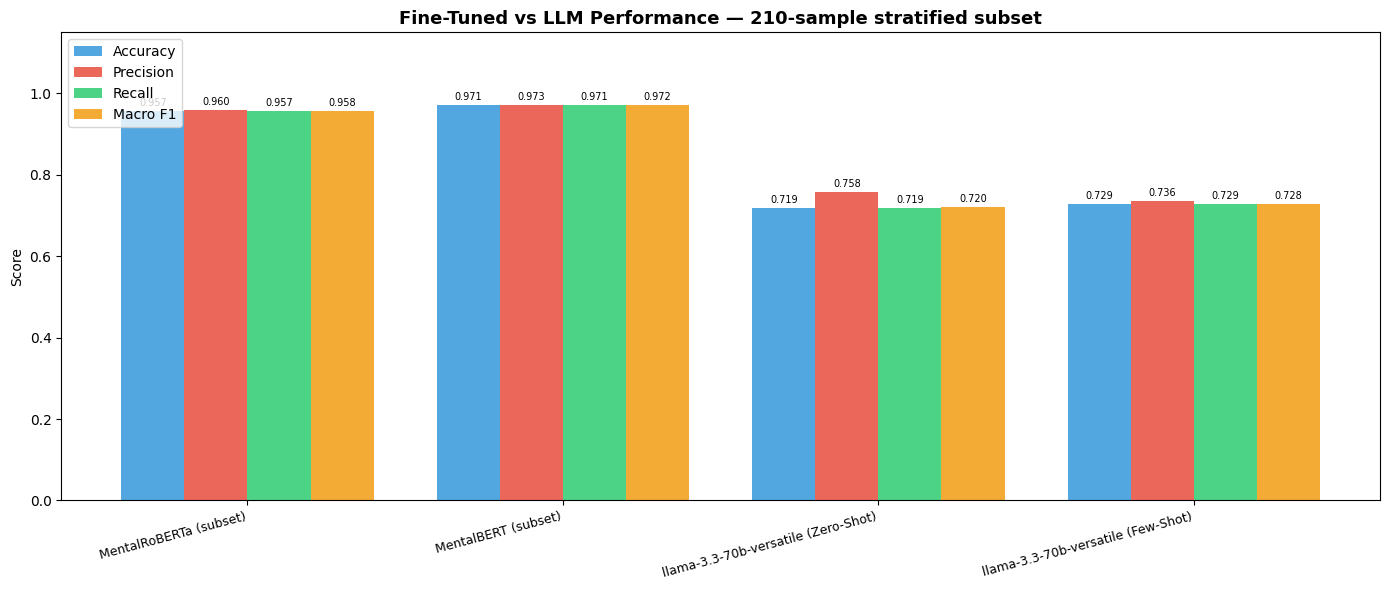

Saved: llm_vs_finetuned_comparison.png


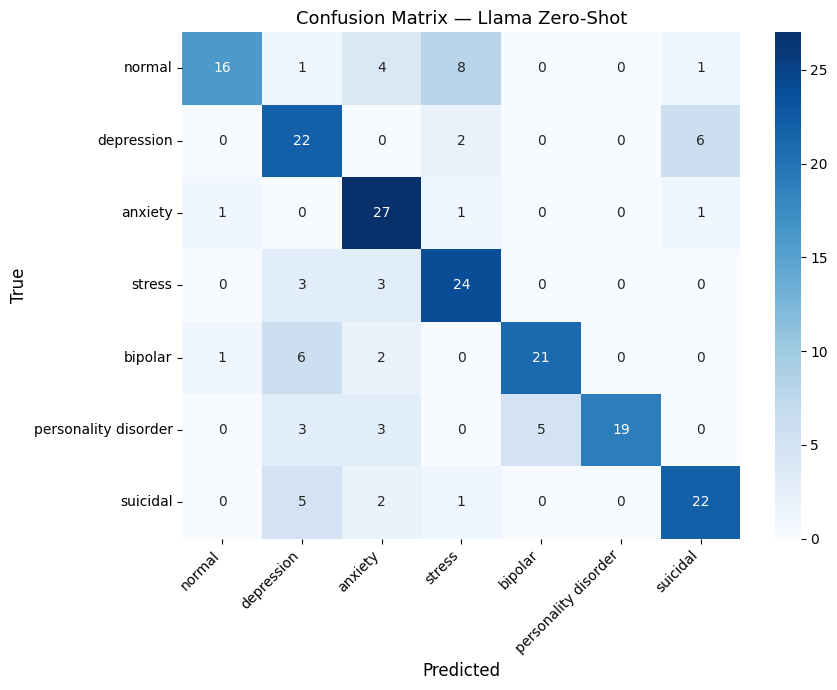

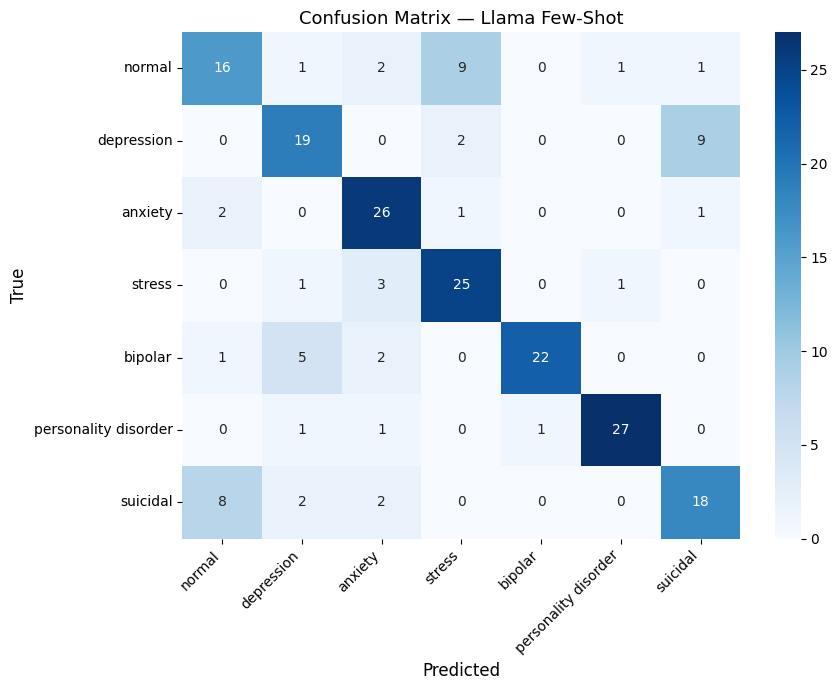

In [60]:
# Subset comparison table + confusion matrices
llm_results = [roberta_subset_results, bert_subset_results,
               llm_zs_results, llm_fs_results]

llm_summary = pd.DataFrame([{
    'Model':          r['model'],
    'Accuracy':       round(r['accuracy'], 4),
    'Precision':      round(r['precision'], 4),
    'Recall':         round(r['recall'], 4),
    'Macro F1':       round(r['f1_macro'], 4),
    'Suicide Recall': round(r['recall_suicide'], 4),
} for r in llm_results])

print("=" * 72)
print(f"LLM vs FINE-TUNED MODELS  —  same {len(llm_test)}-sample stratified subset")
print("=" * 72)
print(llm_summary.to_string(index=False))

# Bar chart — all four models side by side
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'Macro F1']
x = np.arange(len(llm_summary))
width = 0.2
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, llm_summary[metric], width,
                  label=metric, color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(llm_summary['Model'], fontsize=9, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title(f'Fine-Tuned vs LLM Performance — {len(llm_test)}-sample stratified subset',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('llm_vs_finetuned_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: llm_vs_finetuned_comparison.png")

plot_cm(llm_zs_results['cm'], 'Llama Zero-Shot')
plot_cm(llm_fs_results['cm'], 'Llama Few-Shot')